# Complete Breast Cancer Thermography Experiments

This notebook combines **all experiments from both supplied notebooks** without
editing their original code cells. Added cells provide a uniform evaluation
using:

- Accuracy (%)
- F1-Score
- Recall
- AUROC
- Precision
- Sensitivity
- Specificity
- Stratified five-fold cross-validation

Recall and Sensitivity are both shown for paper-table compatibility; for binary
classification they are mathematically identical.

> Run the notebook from top to bottom in a fresh Kaggle session. The original
> dataset paths, model settings, outputs, and experiment code are preserved.


In [1]:

# ============================================================
# ADDED ONLY: SHARED METRIC AND FIVE-FOLD REPORTING UTILITIES
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    precision_score, confusion_matrix, roc_curve
)

METRIC_COLUMNS = [
    "Accuracy (%)", "F1-Score", "Recall", "AUROC",
    "Precision", "Sensitivity", "Specificity"
]

def complete_metrics(y_true, y_pred, y_prob, model_name):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int).ravel()
    classes = np.unique(y_true)

    if len(classes) == 2:
        if y_prob is None:
            y_prob = y_pred
        y_prob = np.asarray(y_prob)
        if y_prob.ndim == 2:
            y_prob = y_prob[:, 1]
        tn, fp, fn, tp = confusion_matrix(
            y_true, y_pred, labels=[0, 1]
        ).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        auc_value = roc_auc_score(y_true, y_prob)
        f1_value = f1_score(y_true, y_pred, zero_division=0)
        recall_value = recall_score(y_true, y_pred, zero_division=0)
        precision_value = precision_score(y_true, y_pred, zero_division=0)
    else:
        cm = confusion_matrix(y_true, y_pred, labels=classes)
        specificities = []
        for i in range(len(classes)):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            specificities.append(tn / (tn + fp) if (tn + fp) else 0.0)
        specificity = float(np.mean(specificities))
        sensitivity = recall_score(
            y_true, y_pred, average="macro", zero_division=0
        )
        recall_value = sensitivity
        f1_value = f1_score(
            y_true, y_pred, average="macro", zero_division=0
        )
        precision_value = precision_score(
            y_true, y_pred, average="macro", zero_division=0
        )
        if y_prob is None:
            auc_value = np.nan
        else:
            auc_value = roc_auc_score(
                y_true, np.asarray(y_prob), multi_class="ovr",
                average="macro"
            )

    return {
        "Model": model_name,
        "Accuracy (%)": 100.0 * accuracy_score(y_true, y_pred),
        "F1-Score": f1_value,
        "Recall": recall_value,
        "AUROC": auc_value,
        "Precision": precision_value,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
    }

def show_results(rows, title):
    table = pd.DataFrame(rows)
    print("\n" + title)
    display(table.round(4))
    return table

# Compatibility alias used by the compiled-notebook evaluation additions.
def show_metric_rows(rows, title):
    return show_results(rows, title)


# ============================================================
# ADDED: GLOBAL STORES FOR COMPARATIVE FIGURES (CONFUSION MATRICES / ROC)
# ============================================================
CONFUSION_MATRICES = {}
ROC_CURVES = {}

def record_diagnostics(model_name, y_true, y_pred, y_prob):
    """Store a model's held-out confusion matrix and ROC curve for later
    comparative figures (used to build the multi-model confusion-matrix
    grid and the comparative AUROC plot requested in the review)."""
    y_true_arr = np.asarray(y_true).astype(int)
    y_pred_arr = np.asarray(y_pred).astype(int).ravel()
    if len(np.unique(y_true_arr)) != 2:
        return
    CONFUSION_MATRICES[model_name] = confusion_matrix(
        y_true_arr, y_pred_arr, labels=[0, 1]
    )
    if y_prob is not None:
        prob_arr = np.asarray(y_prob)
        if prob_arr.ndim == 2:
            prob_arr = prob_arr[:, 1]
        fpr, tpr, _ = roc_curve(y_true_arr, prob_arr)
        ROC_CURVES[model_name] = (fpr, tpr, roc_auc_score(y_true_arr, prob_arr))


def show_five_fold(rows, title):
    table = pd.DataFrame(rows)
    print("\n" + title)
    display(table[["Fold"] + METRIC_COLUMNS].round(4))
    display(pd.DataFrame({
        "Mean": table[METRIC_COLUMNS].mean(),
        "Std": table[METRIC_COLUMNS].std()
    }).T.round(4))
    return table


## Unique experiment implementations

Repeated implementations have been removed. Each section below represents a
distinct model or experimental configuration. Shared reporting utilities are
defined once at the beginning of the notebook.


## 1. CNN-attention + HOG + LightGBM


In [2]:
# ================================
# 1. IMPORTS & SEED
# ================================

import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from skimage.feature import hog
import lightgbm as lgb
import joblib

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [3]:
# ================================
# 2. LOAD DATA
# ================================

IMG_SIZE = 224
dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

images, labels = [], []

for cls, label in [("normal", 0), ("Sick", 1)]:
    path = os.path.join(dataset_path, cls)

    for img in os.listdir(path):
        image = cv2.imread(os.path.join(path, img))
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        images.append(image)
        labels.append(label)

images = np.array(images) / 255.0
labels = np.array(labels)

print("Dataset:", images.shape)

Dataset: (262, 224, 224, 3)


In [4]:
# ================================
# 3. SPLIT DATA
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)

In [5]:
# ================================
# 4. HOG FEATURES
# ================================

def extract_features(images):
    feats = []

    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        hog_feat = hog(gray,
                       orientations=9,
                       pixels_per_cell=(16,16),
                       cells_per_block=(2,2),
                       feature_vector=True)

        mean = np.mean(img, axis=(0,1))
        std  = np.std(img, axis=(0,1))

        feats.append(np.hstack([hog_feat, mean, std]))

    return np.array(feats)

X_train_feat = extract_features(X_train)
X_test_feat  = extract_features(X_test)

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat  = scaler.transform(X_test_feat)

In [6]:
# ================================
# 5. CNN + ATTENTION
# ================================

class CNN_Attention(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.attn = nn.Sequential(
            nn.Conv2d(128,128,1),
            nn.Sigmoid()
        )

        self.fc = nn.Sequential(
            nn.Linear(128*28*28,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.features(x)
        x = x * self.attn(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [7]:
def to_tensor(X,y):
    X = torch.tensor(X.transpose(0,3,1,2), dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X,y)

train_loader = DataLoader(to_tensor(X_train,y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(to_tensor(X_test,y_test), batch_size=32)

In [8]:
model = CNN_Attention().to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(15):
    model.train()
    total_loss = 0

    for xb,yb in train_loader:
        xb,yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: {total_loss:.4f}")

Epoch 1: 4.9455
Epoch 2: 4.1698
Epoch 3: 4.0501
Epoch 4: 3.0336
Epoch 5: 2.5215
Epoch 6: 1.7383
Epoch 7: 1.8648
Epoch 8: 1.4536
Epoch 9: 2.1751
Epoch 10: 1.4401
Epoch 11: 1.4703
Epoch 12: 1.0353
Epoch 13: 0.9269
Epoch 14: 0.5483
Epoch 15: 0.5790


In [9]:
def extract_embeddings(model, loader):
    model.eval()
    embs = []

    with torch.no_grad():
        for xb,_ in loader:
            xb = xb.to(DEVICE)
            x = model.features(xb)
            x = x.mean([2,3])
            embs.append(x.cpu().numpy())

    return np.vstack(embs)

emb_train = extract_embeddings(model, train_loader)
emb_test  = extract_embeddings(model, test_loader)

In [10]:
# ================================
# FEATURE FUSION + CLEANING
# ================================

Xh_train = np.hstack([X_train_feat, emb_train * 2])
Xh_test  = np.hstack([X_test_feat,  emb_test * 2])

# Remove constant features
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.0)
Xh_train = var_selector.fit_transform(Xh_train)
Xh_test  = var_selector.transform(Xh_test)

# Select best features
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=200)
Xh_train = selector.fit_transform(Xh_train, y_train)
Xh_test  = selector.transform(Xh_test)

In [11]:
clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=20,
    min_data_in_leaf=3,
    max_depth=5,
    verbosity=-1
)

# ================================
# CONVERT TO DATAFRAME (ADD HERE)
# ================================

import pandas as pd


Xh_train = pd.DataFrame(Xh_train)
Xh_test  = pd.DataFrame(Xh_test)

clf.fit(Xh_train, y_train)
pred = clf.predict(Xh_test)

In [12]:
print("\nClassification Report:")
print(classification_report(y_test, pred))

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))

probs = clf.predict_proba(Xh_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, probs))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        33
           1       0.86      0.95      0.90        20

    accuracy                           0.92        53
   macro avg       0.92      0.93      0.92        53
weighted avg       0.93      0.92      0.93        53

Accuracy: 0.9245283018867925
F1: 0.9047619047619048
ROC-AUC: 0.9757575757575758


In [13]:
print("\n=== Ablation Study ===")

# HOG
clf_hog = lgb.LGBMClassifier(verbosity=-1)
clf_hog.fit(X_train_feat, y_train)
pred_hog = clf_hog.predict(X_test_feat)

# CNN
clf_cnn = lgb.LGBMClassifier(verbosity=-1)
clf_cnn.fit(emb_train, y_train)
pred_cnn = clf_cnn.predict(emb_test)

print("HOG:", accuracy_score(y_test, pred_hog))
print("CNN:", accuracy_score(y_test, pred_cnn))
print("Proposed:", accuracy_score(y_test, pred))


=== Ablation Study ===
HOG: 0.9245283018867925
CNN: 0.5283018867924528
Proposed: 0.9245283018867925


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, Xh_train, y_train, cv=cv)

print("CV Accuracy:", scores.mean())

CV Accuracy: 0.8518002322880373


In [15]:
joblib.dump(clf, "model.pkl")

['model.pkl']

In [16]:

# ADDED: CNN-ATTENTION + HOG + LIGHTGBM — COMPLETE METRICS AND 5-FOLD CV
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

test_rows = [complete_metrics(
    y_test, pred, probs, "CNN-Attention + HOG + LightGBM"
)]
attention_test_metrics = show_results(
    test_rows, "HELD-OUT TEST METRICS"
)
record_diagnostics("CNN-Attention + HOG + LightGBM (Hybrid)", y_test, pred, probs)

attention_cv_rows = []
attention_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_attention = np.asarray(Xh_train)
for fold, (tr, va) in enumerate(attention_cv.split(X_attention, y_train), 1):
    fold_model = clone(clf)
    fold_model.fit(X_attention[tr], y_train[tr])
    fold_pred = fold_model.predict(X_attention[va])
    fold_prob = fold_model.predict_proba(X_attention[va])
    row = complete_metrics(
        y_train[va], fold_pred, fold_prob,
        "CNN-Attention + HOG + LightGBM"
    )
    row["Fold"] = fold
    attention_cv_rows.append(row)
attention_cv_metrics = show_five_fold(
    attention_cv_rows, "STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,CNN-Attention + HOG + LightGBM,92.4528,0.9048,0.95,0.9758,0.8636,0.95,0.9091


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


STRATIFIED FIVE-FOLD CROSS-VALIDATION


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,83.3333,0.7742,0.7500,0.8894,0.8000,0.7500,0.8846
1,2,73.8095,0.6207,0.5625,0.8486,0.6923,0.5625,0.8462
2,3,92.8571,0.8966,0.8125,0.9760,1.0000,0.8125,1.0000
3,4,88.0952,0.8485,0.8750,0.9255,0.8235,0.8750,0.8846
4,5,87.8049,0.8387,0.8125,0.9750,0.8667,0.8125,0.9200


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,85.1800,0.7957,0.7625,0.9229,0.8365,0.7625,0.9071
Std,7.1942,0.1071,0.1202,0.0552,0.1117,0.1202,0.0581



=== ROC-AUC ===
ROC-AUC: 0.9757575757575758


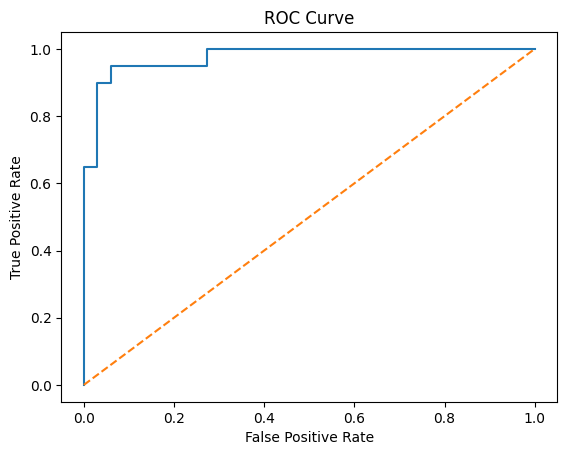

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("\n=== ROC-AUC ===")

probs = clf.predict_proba(Xh_test)[:, 1]

auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", auc)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


=== CONFUSION MATRIX ===
[[30  3]
 [ 1 19]]


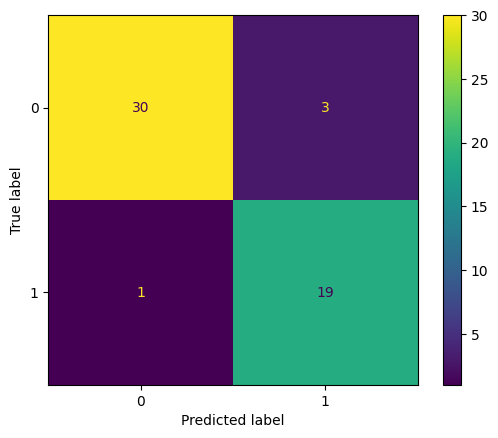

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\n=== CONFUSION MATRIX ===")

cm = confusion_matrix(y_test, pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [19]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

In [20]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # register hooks
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients
        activations = self.activations

        # Global Average Pooling (weights)
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        # Weighted combination
        cam = torch.sum(weights * activations, dim=1)

        cam = cam.squeeze().detach().cpu().numpy()

        # ReLU
        cam = np.maximum(cam, 0)

        # Normalize
        cam = cam / (cam.max() + 1e-8)

        return cam

In [21]:
target_layer = model.features[-3]  # last conv layer
gradcam = GradCAM(model, target_layer)

In [22]:
def visualize_gradcam(original_img, cam):

    cam = cv2.resize(cam, (224, 224))

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = heatmap * 0.4 + (original_img * 255)

    overlay = np.clip(overlay / 255.0, 0, 1)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

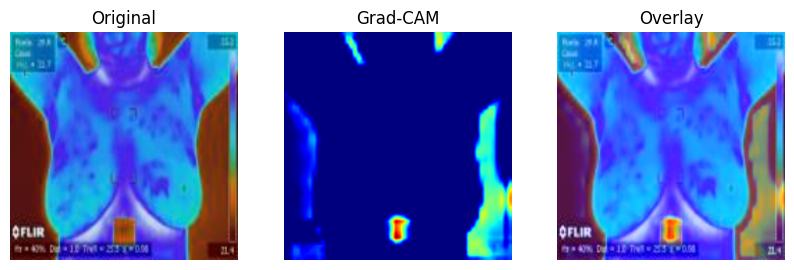

In [23]:
# pick any test image
idx = 0

img = X_test[idx]

# convert to tensor
input_tensor = torch.tensor(
    img.transpose(2,0,1),
    dtype=torch.float32
).unsqueeze(0).to(DEVICE)

# generate cam
cam = gradcam.generate(input_tensor)

# visualize
visualize_gradcam(img, cam)

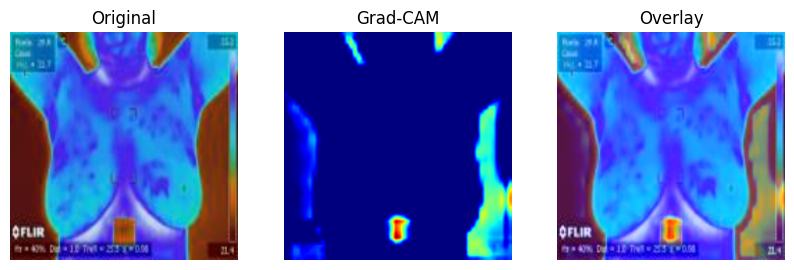

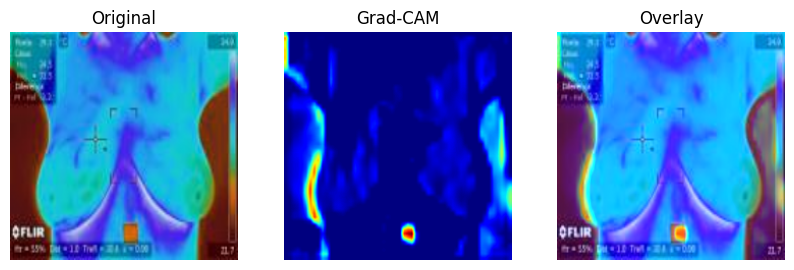

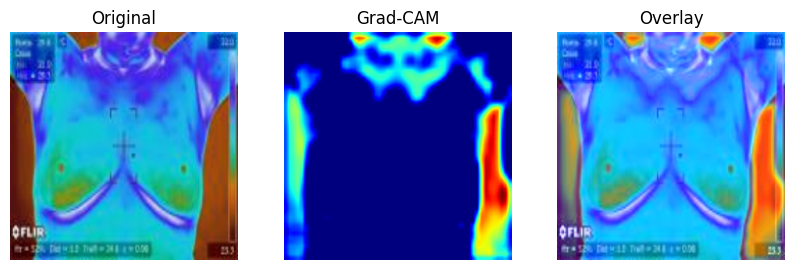

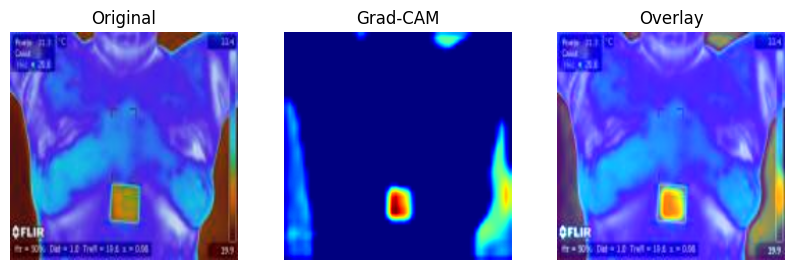

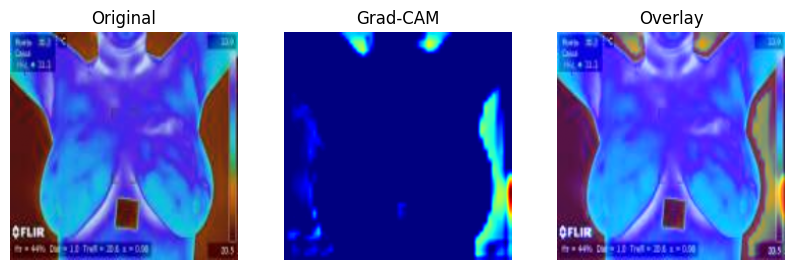

In [24]:
for i in range(5):
    img = X_test[i]

    input_tensor = torch.tensor(
        img.transpose(2,0,1),
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    cam = gradcam.generate(input_tensor)

    visualize_gradcam(img, cam)

In [25]:
print("Feature variance:", np.var(Xh_train, axis=0).mean())
print(Xh_train.shape)
print(np.mean(Xh_train), np.std(Xh_train))

Feature variance: 1.0
(209, 200)
-5.3141967169139074e-17 0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
195    1.0
196    1.0
197    1.0
198    1.0
199    1.0
Length: 200, dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


### Shared dataset inspection for Experiments 2–4


In [26]:
dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

print(os.listdir(dataset_path))

['normal', 'Sick', 'Unknown_class']


Images shape: (262, 224, 224, 3)
Labels shape: (262,)


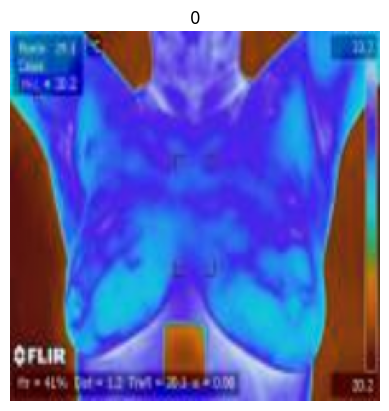

Train: (167, 224, 224, 3)
Validation: (42, 224, 224, 3)
Test: (53, 224, 224, 3)
Number of Normal Images: 162
Number of Sick Images: 100
Total Images: 262


In [27]:
IMG_SIZE = 224
images = []
labels = []

# -------- LOAD NORMAL IMAGES --------
normal_path = os.path.join(dataset_path, "normal")

for img in os.listdir(normal_path):

    img_path = os.path.join(normal_path, img)

    image = cv2.imread(img_path)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    images.append(image)
    labels.append(0)   # Normal = 0


# -------- LOAD SICK IMAGES --------
sick_path = os.path.join(dataset_path, "Sick")

for img in os.listdir(sick_path):

    img_path = os.path.join(sick_path, img)

    image = cv2.imread(img_path)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    images.append(image)
    labels.append(1)   # Abnormal = 1


# -------- CONVERT TO NUMPY ARRAYS --------
images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)


# -------- NORMALIZE PIXEL VALUES --------
images = images / 255.0


# -------- DISPLAY SAMPLE IMAGE --------
plt.imshow(images[0])
plt.title(labels[0])
plt.axis("off")
plt.show()


# -------- TRAIN / TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42
)


# -------- TRAIN / VALIDATION SPLIT --------
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)


# -------- CHECK DATASET SIZES --------
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
normal_count = len(os.listdir(normal_path))
sick_count = len(os.listdir(sick_path))

print("Number of Normal Images:", normal_count)
print("Number of Sick Images:", sick_count)
print("Total Images:", normal_count + sick_count)

## 3. ResNet50 transfer-learning baseline


In [28]:
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

I0000 00:00:1785146162.678796      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12122 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785146162.681094      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
1/6 ━━━━━━━━━━━━━━━━━━━━ 1:11 14s/step - accuracy: 0.6562 - loss: 0.6837

I0000 00:00:1785146181.178284      80 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6108 - loss: 0.7125 - val_accuracy: 0.5000 - val_loss: 0.6857
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.5329 - loss: 0.6902 - val_accuracy: 0.5000 - val_loss: 0.8270
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.6527 - loss: 0.7037 - val_accuracy: 0.5000 - val_loss: 0.7296
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6108 - loss: 0.6773 - val_accuracy: 0.5000 - val_loss: 0.6822
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.6587 - loss: 0.6552 - val_accuracy: 0.5000 - val_loss: 0.7134
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.6527 - loss: 0.6352 - val_accuracy: 0.5000 - val_loss: 0.7100
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.6826 - loss: 0.6173 - val_accuracy: 0.5000 - val_loss: 0.6805
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.6347 - loss: 0.6208 - val_accuracy: 0.5000 - val_loss: 0.7183
Epoch

In [29]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test,y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
[[32  0]
 [18  3]]
              precision    recall  f1-score   support

           0       0.64      1.00      0.78        32
           1       1.00      0.14      0.25        21

    accuracy                           0.66        53
   macro avg       0.82      0.57      0.52        53
weighted avg       0.78      0.66      0.57        53



In [30]:

# ADDED: RESNET50 BASELINE — COMPLETE METRICS AND 5-FOLD CV
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import backend as K

resnet_prob = model.predict(X_test, verbose=0).ravel()
resnet_pred = (resnet_prob >= 0.5).astype(int)
resnet_test_metrics = show_results(
    [complete_metrics(
        y_test, resnet_pred, resnet_prob, "ResNet50 baseline"
    )],
    "HELD-OUT TEST METRICS"
)
record_diagnostics("Baseline CNN (ResNet50)", y_test, resnet_pred, resnet_prob)

def build_fold_resnet50():
    base = ResNet50(
        weights="imagenet", include_top=False, input_shape=(224, 224, 3)
    )
    for layer in base.layers:
        layer.trainable = False
    z = GlobalAveragePooling2D()(base.output)
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.5)(z)
    out = Dense(1, activation="sigmoid")(z)
    fold_model = Model(base.input, out)
    fold_model.compile(
        optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
    )
    return fold_model

resnet_cv_rows = []
resnet_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr, va) in enumerate(resnet_cv.split(images, labels), 1):
    K.clear_session()
    fold_model = build_fold_resnet50()
    fold_model.fit(
        images[tr], labels[tr], epochs=10, batch_size=32, verbose=0
    )
    fold_prob = fold_model.predict(images[va], verbose=0).ravel()
    fold_pred = (fold_prob >= 0.5).astype(int)
    row = complete_metrics(
        labels[va], fold_pred, fold_prob, "ResNet50 baseline"
    )
    row["Fold"] = fold
    resnet_cv_rows.append(row)
resnet_cv_metrics = show_five_fold(
    resnet_cv_rows, "STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,ResNet50 baseline,66.0377,0.25,0.1429,0.6696,1.0,0.1429,1.0



STRATIFIED FIVE-FOLD CROSS-VALIDATION


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,64.1509,0.0952,0.05,0.7288,1.0,0.05,1.0
1,2,62.2642,0.0000,0.00,0.7758,0.0,0.00,1.0
2,3,61.5385,0.0000,0.00,0.8234,0.0,0.00,1.0
3,4,61.5385,0.0000,0.00,0.8047,0.0,0.00,1.0
4,5,61.5385,0.0000,0.00,0.8266,0.0,0.00,1.0


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,62.2061,0.0190,0.0100,0.7918,0.2000,0.0100,1.0
Std,1.1317,0.0426,0.0224,0.0406,0.4472,0.0224,0.0


## 4. ResNet50 + HOG + RBF-SVM


In [31]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

from skimage.feature import hog
from skimage.color import rgb2gray

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

# ---------------------------
# 1 LOAD DATASET
# ---------------------------

IMG_SIZE = 224
images = []
labels = []

normal_path = os.path.join(dataset_path, "normal")

for img in os.listdir(normal_path):

    img_path = os.path.join(normal_path, img)

    image = cv2.imread(img_path)
    image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

    images.append(image)
    labels.append(0)

sick_path = os.path.join(dataset_path,"Sick")

for img in os.listdir(sick_path):

    img_path = os.path.join(sick_path,img)

    image = cv2.imread(img_path)
    image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

    images.append(image)
    labels.append(1)

images = np.array(images)
labels = np.array(labels)

print("Dataset:",images.shape)

# normalize
images = images / 255.0


# ---------------------------
# 2 TRAIN TEST SPLIT
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42
)


# ---------------------------
# 3 DEEP FEATURE EXTRACTION
# ---------------------------

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

deep_features = feature_extractor.predict(images)

deep_features = deep_features.reshape(deep_features.shape[0], -1)

print("Deep Features:",deep_features.shape)


# ---------------------------
# 4 HOG FEATURE EXTRACTION
# ---------------------------

hog_features = []

for img in images:

    gray = rgb2gray(img)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2)
    )

    hog_features.append(features)

hog_features = np.array(hog_features)

print("HOG Features:",hog_features.shape)


# ---------------------------
# 5 FEATURE FUSION
# ---------------------------

combined_features = np.concatenate(
    (deep_features, hog_features),
    axis=1
)

print("Combined Features:",combined_features.shape)


# ---------------------------
# 6 PCA DIMENSION REDUCTION
# ---------------------------

pca = PCA(n_components=200)

X_pca = pca.fit_transform(combined_features)

print("After PCA:",X_pca.shape)


# ---------------------------
# 7 TRAIN TEST SPLIT AGAIN
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    labels,
    test_size=0.2,
    random_state=42
)


# ---------------------------
# 8 SVM CLASSIFIER
# ---------------------------

model = SVC(kernel="rbf")

model.fit(X_train,y_train)

predictions = model.predict(X_test)


# ---------------------------
# 9 EVALUATION
# ---------------------------

accuracy = accuracy_score(y_test,predictions)

print("Hybrid Model Accuracy:",accuracy)

print(classification_report(y_test,predictions))

Dataset: (262, 224, 224, 3)
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 663ms/step
Deep Features: (262, 100352)
HOG Features: (262, 6084)
Combined Features: (262, 106436)
After PCA: (262, 200)
Hybrid Model Accuracy: 0.7924528301886793
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        32
           1       0.92      0.52      0.67        21

    accuracy                           0.79        53
   macro avg       0.84      0.75      0.76        53
weighted avg       0.82      0.79      0.78        53



In [32]:

# ADDED: RESNET50 + HOG + SVM — COMPLETE METRICS AND 5-FOLD CV
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

svm_prob_model = SVC(kernel="rbf", probability=True)
svm_prob_model.fit(X_train, y_train)
svm_pred = svm_prob_model.predict(X_test)
svm_prob = svm_prob_model.predict_proba(X_test)
svm_test_metrics = show_results(
    [complete_metrics(
        y_test, svm_pred, svm_prob, "ResNet50 + HOG + RBF-SVM"
    )],
    "HELD-OUT TEST METRICS"
)
record_diagnostics("SVM (RBF)", y_test, svm_pred, svm_prob)

svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_cv_rows = []
for fold, (tr, va) in enumerate(svm_cv.split(X_pca, labels), 1):
    fold_model = SVC(kernel="rbf", probability=True)
    fold_model.fit(X_pca[tr], labels[tr])
    fold_pred = fold_model.predict(X_pca[va])
    fold_prob = fold_model.predict_proba(X_pca[va])
    row = complete_metrics(
        labels[va], fold_pred, fold_prob, "ResNet50 + HOG + RBF-SVM"
    )
    row["Fold"] = fold
    svm_cv_rows.append(row)
svm_cv_metrics = show_five_fold(
    svm_cv_rows, "STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,ResNet50 + HOG + RBF-SVM,79.2453,0.6667,0.5238,0.8899,0.9167,0.5238,0.9688



STRATIFIED FIVE-FOLD CROSS-VALIDATION


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,77.3585,0.6000,0.45,0.8833,0.900,0.45,0.9697
1,2,83.0189,0.7097,0.55,0.9485,1.000,0.55,1.0000
2,3,84.6154,0.7778,0.70,0.9250,0.875,0.70,0.9375
3,4,86.5385,0.7879,0.65,0.9188,1.000,0.65,1.0000
4,5,90.3846,0.8571,0.75,0.9766,1.000,0.75,1.0000


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,84.3832,0.7465,0.6200,0.9304,0.9550,0.6200,0.9814
Std,4.7939,0.0971,0.1204,0.0348,0.0622,0.1204,0.0278


Normal Images: 162
Sick Images: 100


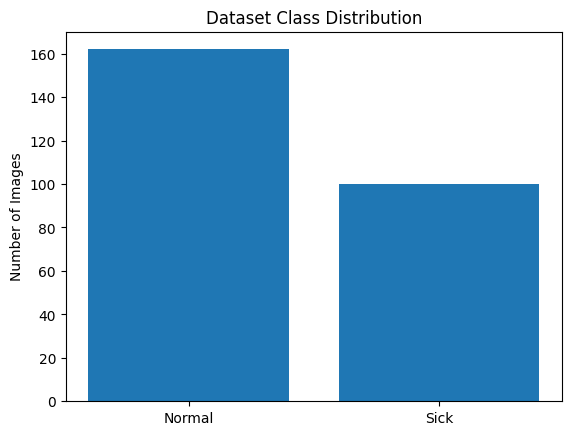

In [33]:
import matplotlib.pyplot as plt
import numpy as np
normal_count = np.sum(labels == 0)
sick_count = np.sum(labels == 1)

print("Normal Images:", normal_count)
print("Sick Images:", sick_count)
classes = ["Normal", "Sick"]
counts = [normal_count, sick_count]

plt.bar(classes, counts)
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.show()

## 5. ResNet50 + HOG + XGBoost—with and without augmentation


In [34]:
# ===============================
# 1. IMPORTS
# ===============================
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from skimage.feature import hog
from skimage.color import rgb2gray

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_auc_score


# ===============================
# 2. LOAD DATA
# ===============================
dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

normal_path = os.path.join(dataset_path, "normal")
sick_path = os.path.join(dataset_path, "Sick")

IMG_SIZE = 224
images, labels = [], []

def load_images(folder, label):
    for img in os.listdir(folder):
        if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        
        path = os.path.join(folder, img)
        image = cv2.imread(path)
        if image is None:
            continue
        
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        images.append(image)
        labels.append(label)

load_images(normal_path, 0)
load_images(sick_path, 1)

images = np.array(images)
labels = np.array(labels)

print("Dataset:", images.shape)


# ===============================
# 3. SPLIT
# ===============================
X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)


# ===============================
# 4. AUGMENTATION (ONLY TRAIN)
# ===============================
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

aug_images, aug_labels = [], []

for i in range(len(X_train_img)):
    img = np.expand_dims(X_train_img[i], axis=0)
    
    count = 0
    for batch in datagen.flow(img, batch_size=1):
        aug_images.append(batch[0])
        aug_labels.append(y_train[i])
        count += 1
        if count == 1:  # only 1 augmentation per image
            break

X_train_aug = np.concatenate((X_train_img, np.array(aug_images)))
y_train_aug = np.concatenate((y_train, np.array(aug_labels)))

print("After Augmentation:", X_train_aug.shape)


# ===============================
# 5. PREPROCESS
# ===============================
X_train_img = preprocess_input(X_train_img)
X_train_aug = preprocess_input(X_train_aug)
X_test_img = preprocess_input(X_test_img)


# ===============================
# 6. FEATURE EXTRACTOR (ResNet50)
# ===============================
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)

feature_extractor = Model(inputs=base_model.input, outputs=x)


def extract_features(data):
    deep = feature_extractor.predict(data, verbose=0)
    
    hog_feat = []
    for img in data:
        gray = rgb2gray(img)
        h = hog(gray, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2))
        hog_feat.append(h)
    
    hog_feat = np.array(hog_feat)
    
    return np.concatenate((deep, hog_feat), axis=1)


# ===============================
# 7. FUNCTION TO TRAIN MODEL
# ===============================
def train_pipeline(X_train_data, y_train_data, X_test_data, y_test_data):
    
    # Extract features
    train_features = extract_features(X_train_data)
    test_features = extract_features(X_test_data)
    
    # PCA
    pca = PCA(n_components=200)
    X_train_pca = pca.fit_transform(train_features)
    X_test_pca = pca.transform(test_features)
    
    # XGBoost
    model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05)
    model.fit(X_train_pca, y_train_data)
    
    # 🔷 Predictions
    preds = model.predict(X_test_pca)
    probs = model.predict_proba(X_test_pca)[:, 1]  # IMPORTANT
    
    # Metrics
    acc = accuracy_score(y_test_data, preds)
    roc_auc = roc_auc_score(y_test_data, probs)
    
    return acc, roc_auc


# ===============================
# 8. RUN BOTH EXPERIMENTS
# ===============================
acc_no_aug, roc_no_aug = train_pipeline(X_train_img, y_train, X_test_img, y_test)
acc_aug, roc_aug = train_pipeline(X_train_aug, y_train_aug, X_test_img, y_test)


# ===============================
# 9. RESULTS
# ===============================
print("\n===== FINAL COMPARISON =====")
print("Without Augmentation:")
print("  Accuracy:", acc_no_aug)
print("  ROC-AUC :", roc_no_aug)

print("\nWith Augmentation:")
print("  Accuracy:", acc_aug)
print("  ROC-AUC :", roc_aug)

Dataset: (262, 224, 224, 3)
After Augmentation: (418, 224, 224, 3)

===== FINAL COMPARISON =====
Without Augmentation:
  Accuracy: 0.9056603773584906
  ROC-AUC : 0.9287878787878787

With Augmentation:
  Accuracy: 0.8490566037735849
  ROC-AUC : 0.9272727272727272


In [35]:

# ============================================================
# ADDED: RESNET50 + HOG + XGBOOST — ALL METRICS + 5-FOLD CV
# ============================================================
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

def fit_predict_xgb_metrics(Xtr, ytr, Xva, yva, name):
    train_features = extract_features(Xtr)
    val_features = extract_features(Xva)
    n_components = min(200, train_features.shape[0] - 1, train_features.shape[1])
    fold_pca = PCA(n_components=n_components)
    train_pca = fold_pca.fit_transform(train_features)
    val_pca = fold_pca.transform(val_features)
    fold_xgb = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        eval_metric="logloss", random_state=42
    )
    fold_xgb.fit(train_pca, ytr)
    pred = fold_xgb.predict(val_pca)
    prob = fold_xgb.predict_proba(val_pca)[:, 1]
    if "Fold" not in name:
        # Only record the two held-out (non-CV-fold) runs as diagnostics.
        record_diagnostics(name, yva, pred, prob)
    return complete_metrics(yva, pred, prob, name)

def augment_once(X_data, y_data, seed):
    fold_gen = ImageDataGenerator(
        rotation_range=10, zoom_range=0.1, horizontal_flip=True
    )
    new_images, new_labels = [], []
    for i, image in enumerate(X_data):
        batch = next(fold_gen.flow(
            np.expand_dims(image, 0), batch_size=1, seed=seed + i
        ))
        new_images.append(batch[0])
        new_labels.append(y_data[i])
    return (
        np.concatenate([X_data, np.asarray(new_images)]),
        np.concatenate([y_data, np.asarray(new_labels)])
    )

# Held-out test metrics using the same two existing experiment settings.
xgb_test_rows = [
    fit_predict_xgb_metrics(
        X_train_img, y_train, X_test_img, y_test,
        "ResNet50 + HOG + XGBoost (without augmentation)"
    ),
    fit_predict_xgb_metrics(
        X_train_aug, y_train_aug, X_test_img, y_test,
        "ResNet50 + HOG + XGBoost (with augmentation)"
    )
]
xgb_test_results = show_metric_rows(
    xgb_test_rows, "RESNET50 + HOG + XGBOOST — HELD-OUT TEST METRICS"
)

xgb_cv_rows = []
xgb_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_preprocessed_images = preprocess_input(images.astype(np.float32).copy())

for fold, (train_idx, val_idx) in enumerate(
    xgb_skf.split(all_preprocessed_images, labels), 1
):
    Xtr = all_preprocessed_images[train_idx]
    Xva = all_preprocessed_images[val_idx]
    ytr, yva = labels[train_idx], labels[val_idx]

    row_no_aug = fit_predict_xgb_metrics(
        Xtr, ytr, Xva, yva,
        f"Without augmentation — Fold {fold}"
    )
    row_no_aug["Setting"] = "Without augmentation"
    row_no_aug["Fold"] = fold
    xgb_cv_rows.append(row_no_aug)

    Xtr_aug, ytr_aug = augment_once(Xtr, ytr, seed=4200 + fold)
    row_aug = fit_predict_xgb_metrics(
        Xtr_aug, ytr_aug, Xva, yva,
        f"With augmentation — Fold {fold}"
    )
    row_aug["Setting"] = "With augmentation"
    row_aug["Fold"] = fold
    xgb_cv_rows.append(row_aug)

xgb_cv_df = pd.DataFrame(xgb_cv_rows)
metric_cols = [
    "Accuracy (%)", "F1-Score", "Recall", "AUROC",
    "Precision", "Sensitivity", "Specificity"
]
display(xgb_cv_df[["Setting", "Fold"] + metric_cols].round(4))
display(
    xgb_cv_df.groupby("Setting")[metric_cols].agg(["mean", "std"]).round(4)
)



RESNET50 + HOG + XGBOOST — HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,ResNet50 + HOG + XGBoost (without augmentation),90.5660,0.8571,0.75,0.9288,1.0000,0.75,1.0000
1,ResNet50 + HOG + XGBoost (with augmentation),88.6792,0.8333,0.75,0.9288,0.9375,0.75,0.9697


,Setting,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,Without augmentation,1,75.4717,0.5806,0.45,0.8212,0.8182,0.45,0.9394
1,With augmentation,1,81.1321,0.6667,0.50,0.8288,1.0000,0.50,1.0000
2,Without augmentation,2,83.0189,0.7273,0.60,0.8955,0.9231,0.60,0.9697
3,With augmentation,2,81.1321,0.6875,0.55,0.8788,0.9167,0.55,0.9697
4,Without augmentation,3,84.6154,0.7778,0.70,0.9000,0.8750,0.70,0.9375
5,With augmentation,3,84.6154,0.7778,0.70,0.8719,0.8750,0.70,0.9375
6,Without augmentation,4,88.4615,0.8235,0.70,0.9344,1.0000,0.70,1.0000
7,With augmentation,4,86.5385,0.8108,0.75,0.8891,0.8824,0.75,0.9375
8,Without augmentation,5,90.3846,0.8571,0.75,0.9562,1.0000,0.75,1.0000
9,With augmentation,5,86.5385,0.7879,0.65,0.9484,1.0000,0.65,1.0000


Accuracy (%)         F1-Score         Recall          \
                             mean     std     mean     std   mean     std   
Setting                                                                     
With augmentation         83.9913  2.7256   0.7461  0.0646   0.63  0.1037   
Without augmentation      84.3904  5.7875   0.7533  0.1082   0.64  0.1194   

                       AUROC         Precision         Sensitivity          \
                        mean     std      mean     std        mean     std   
Setting                                                                      
With augmentation     0.8834  0.0430    0.9348  0.0616        0.63  0.1037   
Without augmentation  0.9015  0.0514    0.9233  0.0793        0.64  0.1194   

                     Specificity          
                            mean     std  
Setting                                   
With augmentation         0.9689  0.0313  
Without augmentation      0.9693  0.0308

## 6. Few-shot CNN + ProtoNet ensemble


In [36]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

DATA_DIR = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

# ================= DATASET =================
class BreastDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


# Load all samples
samples = []
classes = {'normal': 0, 'Sick': 1}

for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    for img in os.listdir(path):
        samples.append((os.path.join(path, img), classes[cls]))

# ================= SPLIT =================
train_samples, val_samples = train_test_split(samples, test_size=0.2, stratify=[s[1] for s in samples])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

train_dataset = BreastDataset(train_samples, transform)
val_dataset = BreastDataset(val_samples, transform)

# ================= SAMPLER =================
labels = [label for _, label in train_samples]
class_counts = np.bincount(labels)
weights = 1. / class_counts
sample_weights = [weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# ================= MODELS =================
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(pretrained=True)
        self.model.fc = nn.Linear(512, 2)

    def forward(self, x):
        return self.model(x)


class ProtoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = models.resnet18(pretrained=True)
        self.encoder.fc = nn.Identity()

    def forward(self, x):
        return self.encoder(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = CNNModel().to(device)
proto_model = ProtoNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-4)

# ================= TRAIN =================
for epoch in range(10):
    cnn_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ================= PROTOTYPES =================
def get_prototypes(model, loader):
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            emb = model(imgs)
            features.append(emb.cpu())
            labels.append(lbls)

    features = torch.cat(features)
    labels = torch.cat(labels)

    prototypes = []
    for c in torch.unique(labels):
        prototypes.append(features[labels == c].mean(0))

    return torch.stack(prototypes)

# ================= ENSEMBLE =================
def ensemble_predict(cnn_model, proto_model, loader, threshold=0.4):
    cnn_model.eval()
    proto_model.eval()

    prototypes = get_prototypes(proto_model, loader).to(device)

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            # CNN
            cnn_out = cnn_model(imgs)
            cnn_prob = torch.softmax(cnn_out, dim=1)

            # Proto
            emb = proto_model(imgs)
            dists = torch.cdist(emb, prototypes)
            proto_prob = torch.softmax(-dists, dim=1)

            # Combine
            final_prob = 0.6 * cnn_prob + 0.4 * proto_prob

            cancer_prob = final_prob[:, 1]
            final_pred = (cancer_prob > threshold).long()

            all_preds.extend(final_pred.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(cancer_prob.cpu().numpy())

    return all_labels, all_preds, all_probs

# ================= EVALUATE =================
y_true, y_pred, y_prob = ensemble_predict(cnn_model, proto_model, val_loader, threshold=0.4)

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


Epoch 1, Loss: 11.0652
Epoch 2, Loss: 8.5315
Epoch 3, Loss: 4.6470
Epoch 4, Loss: 5.7329
Epoch 5, Loss: 4.0264
Epoch 6, Loss: 4.6130
Epoch 7, Loss: 3.6126
Epoch 8, Loss: 2.7866
Epoch 9, Loss: 4.5869
Epoch 10, Loss: 2.1268
Accuracy: 0.8679245283018868

Confusion Matrix:
[[27  6]
 [ 1 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.76      0.95      0.84        20

    accuracy                           0.87        53
   macro avg       0.86      0.88      0.86        53
weighted avg       0.89      0.87      0.87        53



In [37]:

# ADDED: CNN + PROTONET FEW-SHOT ENSEMBLE — METRICS AND 5-FOLD CV
from sklearn.model_selection import StratifiedKFold

fewshot_test_metrics = show_results(
    [complete_metrics(
        y_true, y_pred, y_prob, "CNN + ProtoNet few-shot ensemble"
    )],
    "HELD-OUT TEST METRICS"
)
record_diagnostics("Few-shot Learning (ProtoNet + CNN)", y_true, y_pred, y_prob)

def run_fewshot_fold(train_items, val_items):
    train_ds = BreastDataset(train_items, transform)
    val_ds = BreastDataset(val_items, transform)
    train_labels = np.array([label for _, label in train_items])
    counts = np.bincount(train_labels)
    fold_weights = 1.0 / counts
    sampler = WeightedRandomSampler(
        [fold_weights[label] for label in train_labels],
        len(train_labels)
    )
    tr_loader = DataLoader(train_ds, batch_size=8, sampler=sampler)
    va_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
    fold_cnn = CNNModel().to(device)
    fold_proto = ProtoNet().to(device)
    optimizer = torch.optim.Adam(fold_cnn.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    for _ in range(10):
        fold_cnn.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(fold_cnn(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    prototypes = get_prototypes(fold_proto, tr_loader).to(device)
    true, pred, prob = [], [], []
    fold_cnn.eval()
    fold_proto.eval()
    with torch.no_grad():
        for xb, yb in va_loader:
            xb = xb.to(device)
            cnn_prob = torch.softmax(fold_cnn(xb), dim=1)
            distances = torch.cdist(fold_proto(xb), prototypes)
            proto_prob = torch.softmax(-distances, dim=1)
            final_prob = 0.6 * cnn_prob + 0.4 * proto_prob
            prob.extend(final_prob[:, 1].cpu().numpy())
            pred.extend((final_prob[:, 1] > 0.4).long().cpu().numpy())
            true.extend(yb.numpy())
    return np.asarray(true), np.asarray(pred), np.asarray(prob)

sample_labels = np.array([label for _, label in samples])
fewshot_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fewshot_cv_rows = []
for fold, (tr, va) in enumerate(
    fewshot_cv.split(np.arange(len(samples)), sample_labels), 1
):
    fold_true, fold_pred, fold_prob = run_fewshot_fold(
        [samples[i] for i in tr], [samples[i] for i in va]
    )
    row = complete_metrics(
        fold_true, fold_pred, fold_prob,
        "CNN + ProtoNet few-shot ensemble"
    )
    row["Fold"] = fold
    fewshot_cv_rows.append(row)
fewshot_cv_metrics = show_five_fold(
    fewshot_cv_rows, "STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,CNN + ProtoNet few-shot ensemble,86.7925,0.8444,0.95,0.9636,0.76,0.95,0.8182


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depreca


STRATIFIED FIVE-FOLD CROSS-VALIDATION


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,83.0189,0.7429,0.65,0.9076,0.8667,0.65,0.9394
1,2,86.7925,0.8205,0.80,0.9242,0.8421,0.80,0.9091
2,3,84.6154,0.8095,0.85,0.9688,0.7727,0.85,0.8438
3,4,86.5385,0.8444,0.95,0.9531,0.7600,0.95,0.8125
4,5,86.5385,0.8372,0.90,0.9688,0.7826,0.90,0.8438


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,85.5007,0.8109,0.8300,0.9445,0.8048,0.8300,0.8697
Std,1.6406,0.0404,0.1151,0.0275,0.0468,0.1151,0.0525


## 7. Snapshot + ProtoNet ensemble


In [38]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
DATA_DIR = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

class BreastDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


samples = []
classes = {'normal': 0, 'Sick': 1}

for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    for img in os.listdir(path):
        samples.append((os.path.join(path, img), classes[cls]))

train_samples, val_samples = train_test_split(
    samples, test_size=0.2, stratify=[s[1] for s in samples]
)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

labels = [label for _, label in train_samples]
class_counts = np.bincount(labels)
weights = 1. / class_counts
sample_weights = [weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_dataset = BreastDataset(train_samples, transform)
val_dataset = BreastDataset(val_samples, transform)

train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(pretrained=True)
        self.model.fc = nn.Linear(512, 2)

    def forward(self, x):
        return self.model(x)


class ProtoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = models.resnet18(pretrained=True)
        self.encoder.fc = nn.Identity()

    def forward(self, x):
        return self.encoder(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = CNNModel().to(device)
proto_model = ProtoNet().to(device)

optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=3,   # restart every 3 epochs
    T_mult=1
)



snapshots = []

EPOCHS = 12

for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    #  Save snapshot at restart points
    if (epoch + 1) % 3 == 0:
        snap = CNNModel().to(device)
        snap.load_state_dict(cnn_model.state_dict())
        snapshots.append(snap)
        print(f"Snapshot saved at epoch {epoch+1}")




def get_prototypes(model, loader):
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            emb = model(imgs)
            features.append(emb.cpu())
            labels.append(lbls)

    features = torch.cat(features)
    labels = torch.cat(labels)

    prototypes = []
    for c in torch.unique(labels):
        prototypes.append(features[labels == c].mean(0))

    return torch.stack(prototypes)



def snapshot_ensemble_predict(snapshots, proto_model, loader, threshold=0.4):
    proto_model.eval()
    prototypes = get_prototypes(proto_model, loader).to(device)

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            #  Snapshot predictions
            snap_probs = []

            for model in snapshots:
                model.eval()
                out = model(imgs)
                prob = torch.softmax(out, dim=1)
                snap_probs.append(prob)

            avg_snap_prob = torch.mean(torch.stack(snap_probs), dim=0)

            # Proto predictions
            emb = proto_model(imgs)
            dists = torch.cdist(emb, prototypes)
            proto_prob = torch.softmax(-dists, dim=1)

            # Final ensemble
            final_prob = 0.7 * avg_snap_prob + 0.3 * proto_prob

            cancer_prob = final_prob[:, 1]
            final_pred = (cancer_prob > threshold).long()

            all_preds.extend(final_pred.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(cancer_prob.cpu().numpy())

    return all_labels, all_preds, all_probs

y_true, y_pred, y_prob = snapshot_ensemble_predict(
    snapshots,
    proto_model,
    val_loader,
    threshold=0.4
)

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 19.3428
Epoch 2, Loss: 11.4449
Epoch 3, Loss: 9.5389
Snapshot saved at epoch 3
Epoch 4, Loss: 10.7539
Epoch 5, Loss: 7.1874
Epoch 6, Loss: 6.5705
Snapshot saved at epoch 6
Epoch 7, Loss: 9.6843
Epoch 8, Loss: 8.6822
Epoch 9, Loss: 6.9283
Snapshot saved at epoch 9
Epoch 10, Loss: 5.6862
Epoch 11, Loss: 7.1577
Epoch 12, Loss: 4.4225
Snapshot saved at epoch 12
Accuracy: 0.9056603773584906

Confusion Matrix:
[[31  2]
 [ 3 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.89      0.85      0.87        20

    accuracy                           0.91        53
   macro avg       0.90      0.89      0.90        53
weighted avg       0.91      0.91      0.91        53



In [39]:

# ADDED: SNAPSHOT + PROTONET ENSEMBLE — METRICS AND 5-FOLD CV
from sklearn.model_selection import StratifiedKFold

snapshot_test_metrics = show_results(
    [complete_metrics(
        y_true, y_pred, y_prob, "Snapshot + ProtoNet ensemble"
    )],
    "HELD-OUT TEST METRICS"
)
record_diagnostics("Snapshot Ensemble", y_true, y_pred, y_prob)

def run_snapshot_fold(train_items, val_items):
    train_ds = BreastDataset(train_items, transform)
    val_ds = BreastDataset(val_items, transform)
    train_labels = np.array([label for _, label in train_items])
    counts = np.bincount(train_labels)
    fold_weights = 1.0 / counts
    sampler = WeightedRandomSampler(
        [fold_weights[label] for label in train_labels],
        len(train_labels)
    )
    tr_loader = DataLoader(train_ds, batch_size=8, sampler=sampler)
    va_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
    fold_cnn = CNNModel().to(device)
    fold_proto = ProtoNet().to(device)
    optimizer = torch.optim.Adam(fold_cnn.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=3, T_mult=1
    )
    fold_snapshots = []
    for epoch in range(12):
        fold_cnn.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(fold_cnn(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()
        if (epoch + 1) % 3 == 0:
            snapshot = CNNModel().to(device)
            snapshot.load_state_dict(fold_cnn.state_dict())
            fold_snapshots.append(snapshot)
    prototypes = get_prototypes(fold_proto, tr_loader).to(device)
    true, pred, prob = [], [], []
    fold_proto.eval()
    with torch.no_grad():
        for xb, yb in va_loader:
            xb = xb.to(device)
            snapshot_probs = []
            for snapshot in fold_snapshots:
                snapshot.eval()
                snapshot_probs.append(torch.softmax(snapshot(xb), dim=1))
            avg_snapshot = torch.stack(snapshot_probs).mean(0)
            proto_prob = torch.softmax(
                -torch.cdist(fold_proto(xb), prototypes), dim=1
            )
            final_prob = 0.7 * avg_snapshot + 0.3 * proto_prob
            prob.extend(final_prob[:, 1].cpu().numpy())
            pred.extend((final_prob[:, 1] > 0.4).long().cpu().numpy())
            true.extend(yb.numpy())
    return np.asarray(true), np.asarray(pred), np.asarray(prob)

sample_labels = np.array([label for _, label in samples])
snapshot_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
snapshot_cv_rows = []
for fold, (tr, va) in enumerate(
    snapshot_cv.split(np.arange(len(samples)), sample_labels), 1
):
    fold_true, fold_pred, fold_prob = run_snapshot_fold(
        [samples[i] for i in tr], [samples[i] for i in va]
    )
    row = complete_metrics(
        fold_true, fold_pred, fold_prob, "Snapshot + ProtoNet ensemble"
    )
    row["Fold"] = fold
    snapshot_cv_rows.append(row)
snapshot_cv_metrics = show_five_fold(
    snapshot_cv_rows, "STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,Snapshot + ProtoNet ensemble,90.566,0.8718,0.85,0.9515,0.8947,0.85,0.9394


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depreca


STRATIFIED FIVE-FOLD CROSS-VALIDATION


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,84.9057,0.7647,0.65,0.8970,0.9286,0.65,0.9697
1,2,86.7925,0.8108,0.75,0.9227,0.8824,0.75,0.9394
2,3,86.5385,0.8293,0.85,0.9672,0.8095,0.85,0.8750
3,4,86.5385,0.8444,0.95,0.9625,0.7600,0.95,0.8125
4,5,92.3077,0.9091,1.00,0.9859,0.8333,1.00,0.8750


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,87.4165,0.8317,0.8400,0.9471,0.8428,0.8400,0.8943
Std,2.8355,0.0526,0.1432,0.0362,0.0651,0.1432,0.0616


## 8. SVM kernel comparison and CNN+SVM ensemble


In [40]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

DATA_DIR = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

class BreastDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


samples = []
classes = {'normal': 0, 'Sick': 1}

for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    for img in os.listdir(path):
        samples.append((os.path.join(path, img), classes[cls]))

train_samples, val_samples = train_test_split(
    samples, test_size=0.2, stratify=[s[1] for s in samples]
)



transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = BreastDataset(train_samples, transform)
val_dataset = BreastDataset(val_samples, transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.resnet18(pretrained=True)
        self.base.fc = nn.Identity()  # remove classifier

    def forward(self, x):
        return self.base(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = CNNModel().to(device)



def extract_features(model, loader):
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            emb = model(imgs)
            features.append(emb.cpu().numpy())
            labels.append(lbls.numpy())

    return np.vstack(features), np.hstack(labels)

X_train, y_train = extract_features(cnn_model, train_loader)
X_val, y_val = extract_features(cnn_model, val_loader)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)



kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_results = {}

for kernel in kernels:
    print(f"\nTraining SVM ({kernel})...")

    model = SVC(kernel=kernel, probability=True)

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    svm_results[kernel] = (model, acc)

    print(f"{kernel} Accuracy:", acc)


param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001]
}

grid = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=3)
grid.fit(X_train, y_train)

best_svm = grid.best_estimator_

print("\nBest SVM (RBF tuned):", grid.best_params_)



classifier = nn.Linear(512, 2).to(device)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train simple classifier
for epoch in range(5):
    classifier.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        feats = cnn_model(imgs)
        outputs = classifier(feats)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"CNN Epoch {epoch+1}, Loss: {total_loss:.4f}")



def cnn_predict():
    classifier.eval()
    preds = []

    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            feats = cnn_model(imgs)
            out = classifier(feats)
            pred = torch.argmax(out, dim=1)
            preds.extend(pred.cpu().numpy())

    return preds

cnn_preds = cnn_predict()
cnn_acc = accuracy_score(y_val, cnn_preds)



svm_prob = best_svm.predict_proba(X_val)

cnn_probs = []
classifier.eval()

with torch.no_grad():
    for imgs, _ in val_loader:
        imgs = imgs.to(device)
        feats = cnn_model(imgs)
        out = classifier(feats)
        prob = torch.softmax(out, dim=1)
        cnn_probs.append(prob.cpu().numpy())

cnn_prob = np.vstack(cnn_probs)

# Ensemble
final_prob = 0.6 * cnn_prob + 0.4 * svm_prob
ensemble_pred = np.argmax(final_prob, axis=1)

ensemble_acc = accuracy_score(y_val, ensemble_pred)



print("\n===== MODEL COMPARISON =====")

print(f"CNN Accuracy: {cnn_acc:.4f}")

for k in svm_results:
    print(f"SVM ({k}) Accuracy: {svm_results[k][1]:.4f}")

print(f"Tuned SVM (RBF) Accuracy: {accuracy_score(y_val, best_svm.predict(X_val)):.4f}")

print(f"Ensemble (CNN + SVM) Accuracy: {ensemble_acc:.4f}")



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training SVM (linear)...
linear Accuracy: 0.7547169811320755

Training SVM (rbf)...
rbf Accuracy: 0.7924528301886793

Training SVM (poly)...
poly Accuracy: 0.7924528301886793

Training SVM (sigmoid)...
sigmoid Accuracy: 0.7735849056603774

Best SVM (RBF tuned): {'C': 10, 'gamma': 'scale'}
CNN Epoch 1, Loss: 15.8380
CNN Epoch 2, Loss: 10.0596
CNN Epoch 3, Loss: 8.9536
CNN Epoch 4, Loss: 8.9930
CNN Epoch 5, Loss: 7.6664

===== MODEL COMPARISON =====
CNN Accuracy: 0.8113
SVM (linear) Accuracy: 0.7547
SVM (rbf) Accuracy: 0.7925
SVM (poly) Accuracy: 0.7925
SVM (sigmoid) Accuracy: 0.7736
Tuned SVM (RBF) Accuracy: 0.8113
Ensemble (CNN + SVM) Accuracy: 0.7736


In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

results = []

# CNN
metrics = get_metrics(y_val, cnn_preds)
metrics["Model"] = "CNN"
results.append(metrics)

# SVM kernels
for k in svm_results:
    preds = svm_results[k][0].predict(X_val)
    metrics = get_metrics(y_val, preds)
    metrics["Model"] = f"SVM ({k})"
    results.append(metrics)

# Tuned SVM
metrics = get_metrics(y_val, best_svm.predict(X_val))
metrics["Model"] = "SVM (RBF Tuned)"
results.append(metrics)

# Ensemble
metrics = get_metrics(y_val, ensemble_pred)
metrics["Model"] = "CNN + SVM Ensemble"
results.append(metrics)

df = pd.DataFrame(results)
print(df)

   Accuracy  Precision  Recall        F1               Model
0  0.811321   0.916667    0.55  0.687500                 CNN
1  0.754717   0.640000    0.80  0.711111        SVM (linear)
2  0.792453   0.846154    0.55  0.666667           SVM (rbf)
3  0.792453   1.000000    0.45  0.620690          SVM (poly)
4  0.773585   0.750000    0.60  0.666667       SVM (sigmoid)
5  0.811321   0.750000    0.75  0.750000     SVM (RBF Tuned)
6  0.773585   0.750000    0.60  0.666667  CNN + SVM Ensemble


In [42]:

# ADDED: SVM KERNELS, CNN, AND CNN+SVM ENSEMBLE — COMPLETE METRICS + 5-FOLD CV
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

comparison_rows = []
for kernel, (kernel_model, _) in svm_results.items():
    kernel_pred = kernel_model.predict(X_val)
    kernel_prob = kernel_model.predict_proba(X_val)
    comparison_rows.append(complete_metrics(
        y_val, kernel_pred, kernel_prob, f"SVM ({kernel})"
    ))
    record_diagnostics(f"SVM ({kernel.capitalize()})", y_val, kernel_pred, kernel_prob)
comparison_rows.append(complete_metrics(
    y_val, best_svm.predict(X_val), best_svm.predict_proba(X_val),
    "SVM (RBF tuned)"
))
record_diagnostics(
    "SVM (RBF Tuned)", y_val, best_svm.predict(X_val), best_svm.predict_proba(X_val)
)
comparison_rows.append(complete_metrics(
    y_val, cnn_preds, cnn_prob, "CNN classifier"
))
record_diagnostics("CNN classifier", y_val, cnn_preds, cnn_prob)
comparison_rows.append(complete_metrics(
    y_val, ensemble_pred, final_prob, "CNN + SVM ensemble"
))
record_diagnostics("CNN + SVM Ensemble", y_val, ensemble_pred, final_prob)
svm_comparison_test_metrics = show_results(
    comparison_rows, "HELD-OUT TEST METRICS"
)

X_compare = np.vstack([X_train, X_val])
y_compare = np.concatenate([y_train, y_val])
compare_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
compare_cv_tables = {}
models_for_cv = {
    **{f"SVM ({k})": SVC(kernel=k, probability=True) for k in kernels},
    "SVM (RBF tuned)": clone(best_svm),
}
for name, candidate in models_for_cv.items():
    rows = []
    for fold, (tr, va) in enumerate(compare_cv.split(X_compare, y_compare), 1):
        fold_model = clone(candidate)
        fold_model.fit(X_compare[tr], y_compare[tr])
        fold_pred = fold_model.predict(X_compare[va])
        fold_prob = fold_model.predict_proba(X_compare[va])
        row = complete_metrics(y_compare[va], fold_pred, fold_prob, name)
        row["Fold"] = fold
        rows.append(row)
    compare_cv_tables[name] = show_five_fold(
        rows, f"{name} — STRATIFIED FIVE-FOLD CROSS-VALIDATION"
    )

# CNN classifier and CNN+SVM ensemble use the same five stratified folds.
cnn_rows, ensemble_rows = [], []
for fold, (tr, va) in enumerate(compare_cv.split(X_compare, y_compare), 1):
    fold_classifier = nn.Linear(X_compare.shape[1], 2).to(device)
    fold_optimizer = torch.optim.Adam(
        fold_classifier.parameters(), lr=1e-3
    )
    fold_criterion = nn.CrossEntropyLoss()
    xtr = torch.tensor(X_compare[tr], dtype=torch.float32).to(device)
    ytr = torch.tensor(y_compare[tr], dtype=torch.long).to(device)
    for _ in range(5):
        fold_classifier.train()
        output = fold_classifier(xtr)
        loss = fold_criterion(output, ytr)
        fold_optimizer.zero_grad()
        loss.backward()
        fold_optimizer.step()
    fold_classifier.eval()
    with torch.no_grad():
        cnn_fold_prob = torch.softmax(
            fold_classifier(torch.tensor(
                X_compare[va], dtype=torch.float32
            ).to(device)),
            dim=1
        ).cpu().numpy()
    cnn_fold_pred = cnn_fold_prob.argmax(axis=1)
    cnn_row = complete_metrics(
        y_compare[va], cnn_fold_pred, cnn_fold_prob, "CNN classifier"
    )
    cnn_row["Fold"] = fold
    cnn_rows.append(cnn_row)

    fold_svm = clone(best_svm)
    fold_svm.fit(X_compare[tr], y_compare[tr])
    svm_fold_prob = fold_svm.predict_proba(X_compare[va])
    ensemble_fold_prob = 0.6 * cnn_fold_prob + 0.4 * svm_fold_prob
    ensemble_fold_pred = ensemble_fold_prob.argmax(axis=1)
    ensemble_row = complete_metrics(
        y_compare[va], ensemble_fold_pred, ensemble_fold_prob,
        "CNN + SVM ensemble"
    )
    ensemble_row["Fold"] = fold
    ensemble_rows.append(ensemble_row)

compare_cv_tables["CNN classifier"] = show_five_fold(
    cnn_rows, "CNN classifier — STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)
compare_cv_tables["CNN + SVM ensemble"] = show_five_fold(
    ensemble_rows,
    "CNN + SVM ensemble — STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,SVM (linear),75.4717,0.7111,0.80,0.8606,0.6400,0.80,0.7273
1,SVM (rbf),79.2453,0.6667,0.55,0.8788,0.8462,0.55,0.9394
2,SVM (poly),79.2453,0.6207,0.45,0.8864,1.0000,0.45,1.0000
3,SVM (sigmoid),77.3585,0.6667,0.60,0.8727,0.7500,0.60,0.8788
4,SVM (RBF tuned),81.1321,0.7500,0.75,0.8727,0.7500,0.75,0.8485
5,CNN classifier,81.1321,0.6875,0.55,0.8848,0.9167,0.55,0.9697
6,CNN + SVM ensemble,77.3585,0.6667,0.60,0.8803,0.7500,0.60,0.8788



SVM (linear) — STRATIFIED FIVE-FOLD CROSS-VALIDATION


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,88.6792,0.8571,0.90,0.9212,0.8182,0.90,0.8788
1,2,84.9057,0.8182,0.90,0.9439,0.7500,0.90,0.8182
2,3,78.8462,0.7442,0.80,0.8672,0.6957,0.80,0.7812
3,4,73.0769,0.6500,0.65,0.7922,0.6500,0.65,0.7812
4,5,71.1538,0.6154,0.60,0.7922,0.6316,0.60,0.7812


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,79.3324,0.7370,0.7700,0.8633,0.7091,0.7700,0.8081
Std,7.4947,0.1042,0.1396,0.0707,0.0762,0.1396,0.0426


...

,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,83.0189,0.7692,0.75,0.8424,0.7895,0.75,0.8788
1,2,88.6792,0.8500,0.85,0.9409,0.8500,0.85,0.9091
2,3,84.6154,0.8000,0.80,0.9047,0.8000,0.80,0.8750
3,4,78.8462,0.7027,0.65,0.8531,0.7647,0.65,0.8750
4,5,75.0000,0.6667,0.65,0.7750,0.6842,0.65,0.8125


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,82.0319,0.7577,0.7400,0.8632,0.7777,0.7400,0.8701
Std,5.2781,0.0737,0.0894,0.0634,0.0608,0.0894,0.0352



CNN + SVM ensemble — STRATIFIED FIVE-FOLD CROSS-VALIDATION


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,88.6792,0.8333,0.75,0.9318,0.9375,0.75,0.9697
1,2,86.7925,0.8205,0.80,0.9758,0.8421,0.80,0.9091
2,3,84.6154,0.7895,0.75,0.9297,0.8333,0.75,0.9062
3,4,86.5385,0.7879,0.65,0.8938,1.0000,0.65,1.0000
4,5,78.8462,0.7027,0.65,0.8109,0.7647,0.65,0.8750


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,85.0943,0.7868,0.7200,0.9084,0.8755,0.7200,0.9320
Std,3.7779,0.0509,0.0671,0.0617,0.0929,0.0671,0.0512


## 9. Teacher-assisted LightGBM


Images: (262, 224, 224, 3)
Labels: (262,)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training Teacher...
Epoch 1/15


2026-07-27 10:05:41.004767: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:05:41.141205: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:05:41.470085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:05:41.611564: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:05:41.753097: E external/local_xla/xla/stream_

24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5414 - loss: 0.6937

2026-07-27 10:06:01.662519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:06:01.797959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:06:02.637570: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:06:02.772676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.5427 - loss: 0.6942

...

2026-07-27 10:07:02.786322: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:02.926808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:03.267726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:03.410021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:04.258134: E external/local_xla/xla/stream_

7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

2026-07-27 10:07:13.887669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:14.029351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:14.375812: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:14.519052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:07:15.361273: E external/local_xla/xla/stream_

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step

 Accuracy: 0.9056603773584906

Confusion Matrix:
 [[31  2]
 [ 3 17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.89      0.85      0.87        20

    accuracy                           0.91        53
   macro avg       0.90      0.89      0.90        53
weighted avg       0.91      0.91      0.91        53


ROC-AUC: 0.9878787878787879


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


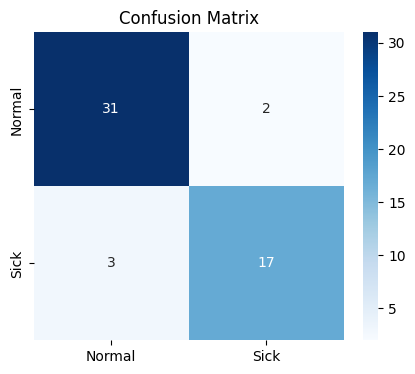


Running 5-Fold CV...
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-07-27 10:11:39.474602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:11:39.615400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:11:39.953539: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 10:11:40.095166: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel 

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

...

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



CV Scores: [0.9245283  0.94339623 0.86538462 0.94230769 0.92307692]
Mean: 0.9197387518142236
Std: 0.02848679871018782

 DONE!


In [43]:
#14/4/26(tried knowledge distillation)
# ===============================
# 1. IMPORTS
# ===============================
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Multiply, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

from skimage.feature import hog
from lightgbm import LGBMClassifier
import joblib

# ===============================
# 2. LOAD DATA
# ===============================
dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

IMG_SIZE = 224
images, labels = [], []

def load_images(folder, label):
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        images.append(image)
        labels.append(label)

load_images(os.path.join(dataset_path, "normal"), 0)
load_images(os.path.join(dataset_path, "Sick"), 1)

images = np.array(images) / 255.0
labels = np.array(labels)

print("Images:", images.shape)
print("Labels:", labels.shape)

# ===============================
# 3. CBAM BLOCK
# ===============================
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(input_feature)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(input_feature)

    dense1 = Dense(channel // ratio, activation='relu')
    dense2 = Dense(channel)

    avg_out = dense2(dense1(avg_pool))
    max_out = dense2(dense1(max_pool))

    channel_attention = tf.keras.activations.sigmoid(avg_out + max_out)
    channel_attention = Reshape((1,1,channel))(channel_attention)

    return Multiply()([input_feature, channel_attention])

# ===============================
# 4. BUILD TEACHER MODEL
# ===============================
def build_teacher():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    
    x = base.output
    x = cbam_block(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    out = Dense(2, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)

    for layer in base.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ===============================
# 5. HOG FEATURES
# ===============================
def extract_hog(images):
    features = []
    for img in images:
        img_uint8 = (img * 255).astype(np.uint8)
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )
        features.append(feat)
    return np.array(features)

# ===============================
# 6. TEMPERATURE SOFTMAX
# ===============================
def softmax_temp(probs, T=3):
    probs = np.clip(probs, 1e-8, 1.0)
    logits = np.log(probs)
    exp = np.exp(logits / T)
    return exp / np.sum(exp, axis=1, keepdims=True)

# ===============================
# 7. TRAIN-TEST SPLIT
# ===============================
X_train_img, X_val_img, y_train_lbl, y_val_lbl = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)

y_train = tf.keras.utils.to_categorical(y_train_lbl, 2)
y_val = tf.keras.utils.to_categorical(y_val_lbl, 2)

# ===============================
# 8. TRAIN TEACHER
# ===============================
teacher = build_teacher()

print("\nTraining Teacher...")
teacher.fit(X_train_img, y_train, validation_data=(X_val_img, y_val),
            epochs=15, batch_size=8, verbose=1)

# ===============================
# 9. DISTILLATION FEATURES
# ===============================
T = 3

train_soft = softmax_temp(teacher.predict(X_train_img), T)
val_soft = softmax_temp(teacher.predict(X_val_img), T)

X_train_hog = extract_hog(X_train_img)
X_val_hog = extract_hog(X_val_img)

X_train_comb = np.hstack([X_train_hog, train_soft])
X_val_comb = np.hstack([X_val_hog, val_soft])

scaler = StandardScaler()
X_train_comb = scaler.fit_transform(X_train_comb)
X_val_comb = scaler.transform(X_val_comb)

# ===============================
# 10. STUDENT MODEL
# ===============================
student = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8
)

student.fit(X_train_comb, y_train_lbl)

# ===============================
# 11. EVALUATION
# ===============================
y_pred = student.predict(X_val_comb)
y_prob = student.predict_proba(X_val_comb)[:,1]

print("\n Accuracy:", accuracy_score(y_val_lbl, y_pred))

cm = confusion_matrix(y_val_lbl, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_val_lbl, y_pred))

print("\nROC-AUC:", roc_auc_score(y_val_lbl, y_prob))

# Plot CM
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Sick"],
            yticklabels=["Normal","Sick"])
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 12. CROSS VALIDATION (CORRECT)
# ===============================
print("\nRunning 5-Fold CV...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, val_idx in skf.split(images, labels):

    X_tr, X_va = images[train_idx], images[val_idx]
    y_tr, y_va = labels[train_idx], labels[val_idx]

    y_tr_cat = tf.keras.utils.to_categorical(y_tr, 2)

    teacher_cv = build_teacher()
    teacher_cv.fit(X_tr, y_tr_cat, epochs=5, verbose=0)

    tr_soft = softmax_temp(teacher_cv.predict(X_tr), T)
    va_soft = softmax_temp(teacher_cv.predict(X_va), T)

    X_tr_hog = extract_hog(X_tr)
    X_va_hog = extract_hog(X_va)

    X_tr_comb = np.hstack([X_tr_hog, tr_soft])
    X_va_comb = np.hstack([X_va_hog, va_soft])

    scaler = StandardScaler()
    X_tr_comb = scaler.fit_transform(X_tr_comb)
    X_va_comb = scaler.transform(X_va_comb)

    model = LGBMClassifier(n_estimators=200)
    model.fit(X_tr_comb, y_tr)

    preds = model.predict(X_va_comb)
    scores.append(accuracy_score(y_va, preds))

scores = np.array(scores)

print("\nCV Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

# ===============================
# 13. SAVE MODELS
# ===============================
teacher.save("teacher_model.h5")
joblib.dump(student, "student_model.pkl")

print("\n DONE!")

In [44]:

# ADDED: TEACHER-ASSISTED LIGHTGBM — COMPLETE METRICS AND 5-FOLD CV
kd_test_metrics = show_results(
    [complete_metrics(
        y_val_lbl, y_pred, y_prob, "Teacher-assisted LightGBM"
    )],
    "HELD-OUT TEST METRICS"
)
record_diagnostics("Knowledge Distillation", y_val_lbl, y_pred, y_prob)

kd_cv_rows = []
kd_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr, va) in enumerate(kd_cv.split(images, labels), 1):
    X_tr, X_va = images[tr], images[va]
    y_tr, y_va = labels[tr], labels[va]
    teacher_fold = build_teacher()
    teacher_fold.fit(
        X_tr, tf.keras.utils.to_categorical(y_tr, 2),
        epochs=5, batch_size=8, verbose=0
    )
    tr_soft = softmax_temp(teacher_fold.predict(X_tr, verbose=0), T)
    va_soft = softmax_temp(teacher_fold.predict(X_va, verbose=0), T)
    tr_comb = np.hstack([extract_hog(X_tr), tr_soft])
    va_comb = np.hstack([extract_hog(X_va), va_soft])
    fold_scaler = StandardScaler()
    tr_comb = fold_scaler.fit_transform(tr_comb)
    va_comb = fold_scaler.transform(va_comb)
    fold_student = LGBMClassifier(n_estimators=200)
    fold_student.fit(tr_comb, y_tr)
    fold_pred = fold_student.predict(va_comb)
    fold_prob = fold_student.predict_proba(va_comb)
    row = complete_metrics(
        y_va, fold_pred, fold_prob, "Teacher-assisted LightGBM"
    )
    row["Fold"] = fold
    kd_cv_rows.append(row)
kd_cv_metrics = show_five_fold(
    kd_cv_rows, "STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,Teacher-assisted LightGBM,90.566,0.8718,0.85,0.9879,0.8947,0.85,0.9394


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-07-27 10:19:45.716107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-


STRATIFIED FIVE-FOLD CROSS-VALIDATION


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,92.4528,0.8889,0.80,0.9697,1.0000,0.80,1.0000
1,2,94.3396,0.9189,0.85,0.9894,1.0000,0.85,1.0000
2,3,82.6923,0.7692,0.75,0.9500,0.7895,0.75,0.8750
3,4,94.2308,0.9268,0.95,0.9891,0.9048,0.95,0.9375
4,5,92.3077,0.8947,0.85,0.9953,0.9444,0.85,0.9688


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,91.2046,0.8797,0.8400,0.9787,0.9277,0.8400,0.9562
Std,4.8534,0.0638,0.0742,0.0187,0.0871,0.0742,0.0523


## 10. Teacher-assisted stacking ensemble


Images: (262, 224, 224, 3)
Labels: (262,)

Training Teacher...
Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 54s 992ms/step - accuracy: 0.5789 - loss: 0.6773 - val_accuracy: 0.6226 - val_loss: 0.6644
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6124 - loss: 0.6754 - val_accuracy: 0.6226 - val_loss: 0.6630
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6172 - loss: 0.6735 - val_accuracy: 0.6226 - val_loss: 0.6682
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5933 - loss: 0.6480 - val_accuracy: 0.6226 - val_loss: 0.6722
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6172 - loss: 0.6990 - val_accuracy: 0.6226 - val_loss: 0.6708
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6172 - loss: 0.6689 - val_accuracy: 0.6226 - val_loss: 0.6661
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5837 - loss: 0.6869 - val_accuracy: 0.6226 - val_loss: 0.6623
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


 STACKING Accuracy: 0.9622641509433962

Confusion Matrix:
 [[32  1]
 [ 1 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.95      0.95      0.95        20

    accuracy                           0.96        53
   macro avg       0.96      0.96      0.96        53
weighted avg       0.96      0.96      0.96        53


ROC-AUC: 0.9893939393939394


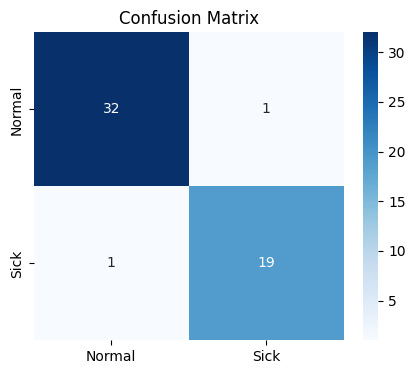


 DONE!


In [45]:
#14/4/26 stacking ensemble(Train multiple ML models Combine their outputs using a meta-model)
# ===============================
# 1. IMPORTS
# ===============================
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Multiply, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from skimage.feature import hog
from lightgbm import LGBMClassifier
import joblib

# ===============================
# 2. LOAD DATA
# ===============================
dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

IMG_SIZE = 224
images, labels = [], []

def load_images(folder, label):
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        images.append(image)
        labels.append(label)

load_images(os.path.join(dataset_path, "normal"), 0)
load_images(os.path.join(dataset_path, "Sick"), 1)

images = np.array(images) / 255.0
labels = np.array(labels)

print("Images:", images.shape)
print("Labels:", labels.shape)

# ===============================
# 3. CBAM BLOCK
# ===============================
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(input_feature)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(input_feature)

    dense1 = Dense(channel // ratio, activation='relu')
    dense2 = Dense(channel)

    avg_out = dense2(dense1(avg_pool))
    max_out = dense2(dense1(max_pool))

    attention = tf.keras.activations.sigmoid(avg_out + max_out)
    attention = Reshape((1,1,channel))(attention)

    return Multiply()([input_feature, attention])

# ===============================
# 4. BUILD TEACHER
# ===============================
def build_teacher():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

    x = base.output
    x = cbam_block(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    out = Dense(2, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)

    for layer in base.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ===============================
# 5. HOG FEATURES
# ===============================
def extract_hog(images):
    features = []
    for img in images:
        img_uint8 = (img * 255).astype(np.uint8)
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )
        features.append(feat)
    return np.array(features)

# ===============================
# 6. TEMPERATURE SOFTMAX
# ===============================
def softmax_temp(probs, T=3):
    probs = np.clip(probs, 1e-8, 1.0)
    logits = np.log(probs)
    exp = np.exp(logits / T)
    return exp / np.sum(exp, axis=1, keepdims=True)

# ===============================
# 7. TRAIN-TEST SPLIT
# ===============================
X_train_img, X_val_img, y_train_lbl, y_val_lbl = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)

y_train = tf.keras.utils.to_categorical(y_train_lbl, 2)
y_val = tf.keras.utils.to_categorical(y_val_lbl, 2)

# ===============================
# 8. TRAIN TEACHER
# ===============================
teacher = build_teacher()

print("\nTraining Teacher...")
teacher.fit(X_train_img, y_train,
            validation_data=(X_val_img, y_val),
            epochs=15, batch_size=8, verbose=1)

# ===============================
# 9. DISTILLATION FEATURES
# ===============================
T = 3

train_soft = softmax_temp(teacher.predict(X_train_img), T)
val_soft = softmax_temp(teacher.predict(X_val_img), T)

X_train_hog = extract_hog(X_train_img)
X_val_hog = extract_hog(X_val_img)

X_train_comb = np.hstack([X_train_hog, train_soft])
X_val_comb = np.hstack([X_val_hog, val_soft])

scaler = StandardScaler()
X_train_comb = scaler.fit_transform(X_train_comb)
X_val_comb = scaler.transform(X_val_comb)

# ===============================
# 10. STACKING ENSEMBLE
# ===============================
def stacking_train(X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models = [
        LGBMClassifier(n_estimators=200),
        SVC(probability=True),
        RandomForestClassifier(n_estimators=200),
        LogisticRegression(max_iter=1000)
    ]

    meta_features = np.zeros((X.shape[0], len(models)))

    for i, model in enumerate(models):
        oof = np.zeros(X.shape[0])

        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_va = X[train_idx], X[val_idx]
            y_tr = y[train_idx]

            model.fit(X_tr, y_tr)
            oof[val_idx] = model.predict_proba(X_va)[:,1]

        meta_features[:, i] = oof

    meta_model = LogisticRegression(max_iter=1000)
    meta_model.fit(meta_features, y)

    return models, meta_model

def stacking_predict(models, meta_model, X):
    meta_features = np.column_stack([
        model.predict_proba(X)[:,1] for model in models
    ])
    return meta_model.predict(meta_features), meta_features.mean(axis=1)

# Train stacking
base_models, meta_model = stacking_train(X_train_comb, y_train_lbl)

# ===============================
# 11. EVALUATION
# ===============================
y_pred, y_prob = stacking_predict(base_models, meta_model, X_val_comb)

print("\n STACKING Accuracy:", accuracy_score(y_val_lbl, y_pred))

cm = confusion_matrix(y_val_lbl, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_val_lbl, y_pred))

print("\nROC-AUC:", roc_auc_score(y_val_lbl, y_prob))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Sick"],
            yticklabels=["Normal","Sick"])
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 12. SAVE MODELS
# ===============================
teacher.save("teacher_model.h5")
joblib.dump((base_models, meta_model), "stacking_model.pkl")

print("\n DONE!")

In [46]:

# ADDED: TEACHER-ASSISTED STACKING — COMPLETE METRICS AND 5-FOLD CV
teacher_stack_test_metrics = show_results(
    [complete_metrics(
        y_val_lbl, y_pred, y_prob, "Teacher-assisted stacking ensemble"
    )],
    "HELD-OUT TEST METRICS"
)
record_diagnostics("Stacking Ensemble", y_val_lbl, y_pred, y_prob)

teacher_stack_cv_rows = []
teacher_stack_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr, va) in enumerate(
    teacher_stack_cv.split(images, labels), 1
):
    X_tr, X_va = images[tr], images[va]
    y_tr, y_va = labels[tr], labels[va]
    teacher_fold = build_teacher()
    teacher_fold.fit(
        X_tr, tf.keras.utils.to_categorical(y_tr, 2),
        epochs=5, batch_size=8, verbose=0
    )
    tr_soft = softmax_temp(teacher_fold.predict(X_tr, verbose=0), T)
    va_soft = softmax_temp(teacher_fold.predict(X_va, verbose=0), T)
    tr_comb = np.hstack([extract_hog(X_tr), tr_soft])
    va_comb = np.hstack([extract_hog(X_va), va_soft])
    fold_scaler = StandardScaler()
    tr_comb = fold_scaler.fit_transform(tr_comb)
    va_comb = fold_scaler.transform(va_comb)
    fold_bases, fold_meta = stacking_train(tr_comb, y_tr)
    fold_pred, fold_prob = stacking_predict(
        fold_bases, fold_meta, va_comb
    )
    row = complete_metrics(
        y_va, fold_pred, fold_prob, "Teacher-assisted stacking ensemble"
    )
    row["Fold"] = fold
    teacher_stack_cv_rows.append(row)
teacher_stack_cv_metrics = show_five_fold(
    teacher_stack_cv_rows, "STRATIFIED FIVE-FOLD CROSS-VALIDATION"
)



HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,Teacher-assisted stacking ensemble,96.2264,0.95,0.95,0.9894,0.95,0.95,0.9697


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


STRATIFIED FIVE-FOLD CROSS-VALIDATION


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,86.7925,0.7879,0.65,0.9364,1.0000,0.65,1.0000
1,2,90.5660,0.8571,0.75,0.9485,1.0000,0.75,1.0000
2,3,90.3846,0.8780,0.90,0.9734,0.8571,0.90,0.9062
3,4,90.3846,0.8718,0.85,0.9609,0.8947,0.85,0.9375
4,5,92.3077,0.9000,0.90,0.9938,0.9000,0.90,0.9375


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,90.0871,0.8590,0.8100,0.9626,0.9304,0.8100,0.9562
Std,2.0120,0.0426,0.1084,0.0222,0.0657,0.1084,0.0419


## 11. EfficientNet-CBAM + HOG stacking ensemble


Dataset: (262, 224, 224, 3)
Extracting HOG...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 


Extracting EfficientNet features...

=== FINAL STACKING RESULTS ===
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        33
           1       0.90      0.95      0.93        20

    accuracy                           0.94        53
   macro avg       0.94      0.94      0.94        53
weighted avg       0.94      0.94      0.94        53

Accuracy: 0.9433962264150944
F1 Score: 0.926829268292683


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


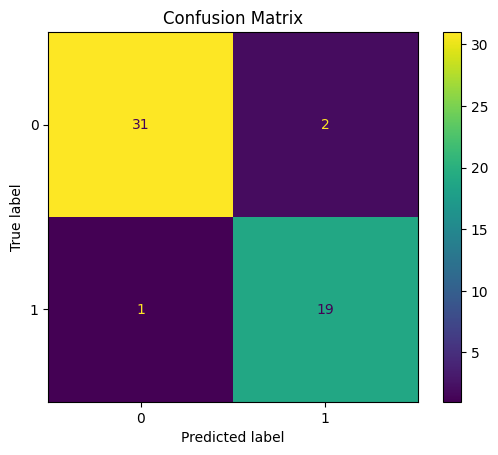

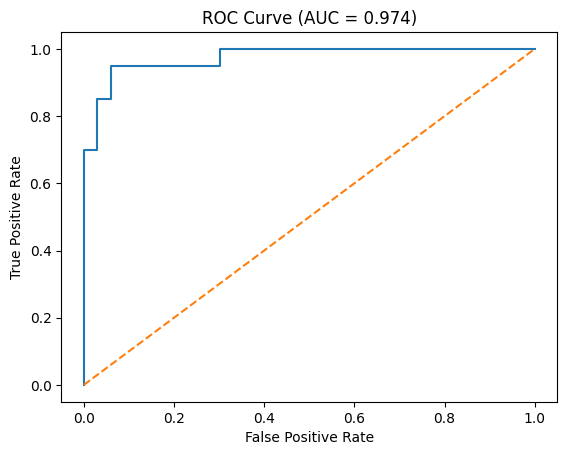

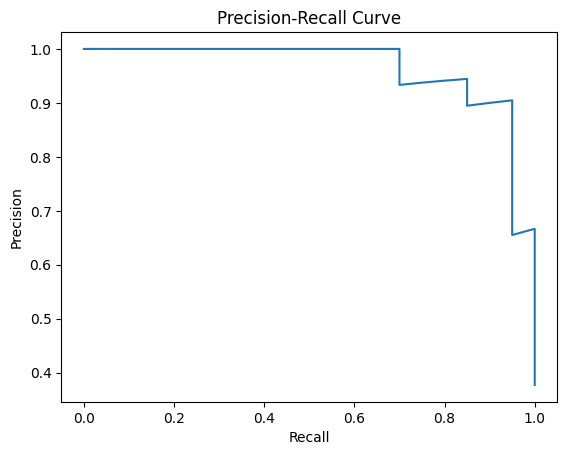

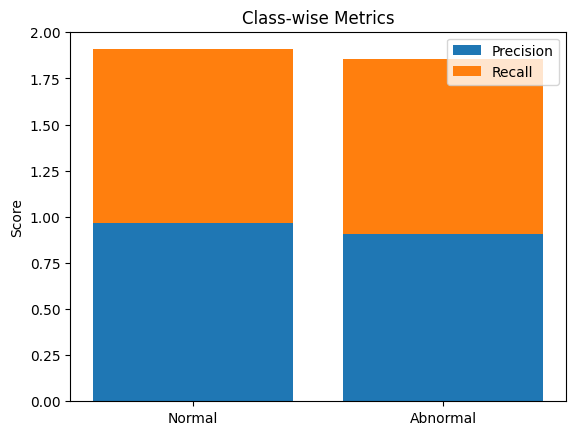

In [47]:
#6/4/2026
import os
import cv2
import numpy as np
import torch
import torch.nn as nn

from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

import lightgbm as lgb
from skimage.feature import hog

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

images = []
labels = []

dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"  # CHANGE

normal_path = os.path.join(dataset_path, "normal")
sick_path   = os.path.join(dataset_path, "Sick")

for img in os.listdir(normal_path):
    im = cv2.imread(os.path.join(normal_path, img))
    im = cv2.resize(im, (IMG_SIZE, IMG_SIZE))
    images.append(im)
    labels.append(0)

for img in os.listdir(sick_path):
    im = cv2.imread(os.path.join(sick_path, img))
    im = cv2.resize(im, (IMG_SIZE, IMG_SIZE))
    images.append(im)
    labels.append(1)

images = np.array(images) / 255.0
labels = np.array(labels)

print("Dataset:", images.shape)
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)
def extract_hog(images):
    feats = []

    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        hog_feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(16,16),
            cells_per_block=(2,2),
            feature_vector=True
        )

        feats.append(hog_feat)

    return np.array(feats)

print("Extracting HOG...")
X_train_hog = extract_hog(X_train)
X_test_hog  = extract_hog(X_test)

scaler = StandardScaler()
X_train_hog = scaler.fit_transform(X_train_hog)
X_test_hog  = scaler.transform(X_test_hog)
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))

        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg, max], dim=1)
        x = self.conv(x)

        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x
class EfficientNet_CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.efficientnet_b0(pretrained=True)

        self.features = base.features
        self.cbam = CBAM(1280)  # EfficientNet last layer channels
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)   
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return x

model = EfficientNet_CBAM().to(DEVICE)
model.eval()
def extract_deep(model, X):
    feats = []

    with torch.no_grad():
        for i in range(0, len(X), 32):
            batch = X[i:i+32]

            xb = torch.tensor(
                batch.transpose(0,3,1,2),
                dtype=torch.float32
            ).to(DEVICE)

            out = model(xb)
            feats.append(out.cpu().numpy())

    return np.vstack(feats)

print("Extracting EfficientNet features...")
X_train_deep = extract_deep(model, X_train)
X_test_deep  = extract_deep(model, X_test)
X_train_combined = np.hstack([X_train_hog, X_train_deep])
X_test_combined  = np.hstack([X_test_hog,  X_test_deep])
selector = SelectKBest(f_classif, k=300)

X_train_combined = selector.fit_transform(X_train_combined, y_train)
X_test_combined  = selector.transform(X_test_combined)
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=20,
    min_data_in_leaf=3,
    verbosity=-1
)

svm_model = SVC(probability=True)
lr_model  = LogisticRegression(max_iter=1000)

lgb_model.fit(X_train_combined, y_train)
svm_model.fit(X_train_combined, y_train)
lr_model.fit(X_train_combined, y_train)
train_meta = np.column_stack([
    lgb_model.predict_proba(X_train_combined)[:,1],
    svm_model.predict_proba(X_train_combined)[:,1],
    lr_model.predict_proba(X_train_combined)[:,1],
])

test_meta = np.column_stack([
    lgb_model.predict_proba(X_test_combined)[:,1],
    svm_model.predict_proba(X_test_combined)[:,1],
    lr_model.predict_proba(X_test_combined)[:,1],
])
meta_model = LogisticRegression()
meta_model.fit(train_meta, y_train)

final_pred = meta_model.predict(test_meta)
print("\n=== FINAL STACKING RESULTS ===")

print(classification_report(y_test, final_pred))

print("Accuracy:", accuracy_score(y_test, final_pred))
print("F1 Score:", f1_score(y_test, final_pred))
#graphs and result documentation for the above pipeline
#confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()
#roc curve
from sklearn.metrics import roc_curve, roc_auc_score

probs = meta_model.predict_proba(test_meta)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")

plt.show()
#precision-recall curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()
from sklearn.metrics import classification_report

report = classification_report(y_test, final_pred, output_dict=True)

classes = ['Normal', 'Abnormal']
precision_vals = [report['0']['precision'], report['1']['precision']]
recall_vals    = [report['0']['recall'], report['1']['recall']]
f1_vals        = [report['0']['f1-score'], report['1']['f1-score']]

x = range(len(classes))

plt.figure()
plt.bar(x, precision_vals, label="Precision")
plt.bar(x, recall_vals, bottom=precision_vals, label="Recall")

plt.xticks(x, classes)
plt.ylabel("Score")
plt.title("Class-wise Metrics")
plt.legend()

plt.show()

In [48]:

# ============================================================
# ADDED: EFFICIENTNET-CBAM STACKING — METRICS + 5-FOLD CV
# ============================================================
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

stack_prob = meta_model.predict_proba(test_meta)[:, 1]
stack_test_results = show_metric_rows(
    [complete_metrics(
        y_test, final_pred, stack_prob,
        "EfficientNet-CBAM + HOG stacking ensemble"
    )],
    "EFFICIENTNET-CBAM STACKING — HELD-OUT TEST METRICS"
)
record_diagnostics("CBAM + LightGBM", y_test, final_pred, stack_prob)

def stacking_fold_metrics(Xtr, ytr, Xva, yva, fold):
    fold_lgb = clone(lgb_model)
    fold_svm = clone(svm_model)
    fold_lr = clone(lr_model)

    for base in (fold_lgb, fold_svm, fold_lr):
        base.fit(Xtr, ytr)

    meta_train = np.column_stack([
        fold_lgb.predict_proba(Xtr)[:, 1],
        fold_svm.predict_proba(Xtr)[:, 1],
        fold_lr.predict_proba(Xtr)[:, 1],
    ])
    meta_val = np.column_stack([
        fold_lgb.predict_proba(Xva)[:, 1],
        fold_svm.predict_proba(Xva)[:, 1],
        fold_lr.predict_proba(Xva)[:, 1],
    ])

    fold_meta = LogisticRegression(max_iter=1000, random_state=42)
    fold_meta.fit(meta_train, ytr)
    pred = fold_meta.predict(meta_val)
    prob = fold_meta.predict_proba(meta_val)[:, 1]
    row = complete_metrics(
        yva, pred, prob, f"EfficientNet-CBAM stacking — Fold {fold}"
    )
    row["Fold"] = fold
    return row

X_stack_all = np.vstack([X_train_combined, X_test_combined])
y_stack_all = np.concatenate([y_train, y_test])
stack_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stack_cv_rows = []

for fold, (train_idx, val_idx) in enumerate(
    stack_skf.split(X_stack_all, y_stack_all), 1
):
    stack_cv_rows.append(stacking_fold_metrics(
        X_stack_all[train_idx], y_stack_all[train_idx],
        X_stack_all[val_idx], y_stack_all[val_idx],
        fold
    ))

stack_cv_df = pd.DataFrame(stack_cv_rows)
metric_cols = [
    "Accuracy (%)", "F1-Score", "Recall", "AUROC",
    "Precision", "Sensitivity", "Specificity"
]
display(stack_cv_df[["Fold"] + metric_cols].round(4))
display(pd.DataFrame({
    "Mean": stack_cv_df[metric_cols].mean(),
    "Std": stack_cv_df[metric_cols].std()
}).T.round(4))



EFFICIENTNET-CBAM STACKING — HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,EfficientNet-CBAM + HOG stacking ensemble,94.3396,0.9268,0.95,0.9742,0.9048,0.95,0.9394


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,79.2453,0.7027,0.65,0.9061,0.7647,0.65,0.8788
1,2,90.5660,0.8571,0.75,0.9606,1.0000,0.75,1.0000
2,3,84.6154,0.7500,0.60,0.9688,1.0000,0.60,1.0000
3,4,88.4615,0.8421,0.80,0.9594,0.8889,0.80,0.9375
4,5,88.4615,0.8421,0.80,0.9531,0.8889,0.80,0.9375


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,86.2700,0.7988,0.7200,0.9496,0.9085,0.7200,0.9508
Std,4.4762,0.0685,0.0908,0.0250,0.0977,0.0908,0.0509


## 12. HOG + XGBoost baseline


In [49]:
# ===============================
# 1. IMPORTS
# ===============================
import os
import cv2
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from skimage.feature import hog

from xgboost import XGBClassifier


# ===============================
# 2. LOAD DATA
# ===============================
IMG_SIZE = 224
dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

images = []
labels = []

for cls, label in [("normal", 0), ("Sick", 1)]:
    path = os.path.join(dataset_path, cls)
    
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        
        image = cv2.imread(img_path)
        if image is None:
            continue
        
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        images.append(image)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Dataset shape:", images.shape)


# ===============================
# 3. FEATURE EXTRACTION (HOG)
# ===============================
def extract_hog_features(images):
    features = []
    
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        hog_feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(16,16),
            cells_per_block=(2,2),
            feature_vector=True
        )
        
        features.append(hog_feat)
    
    return np.array(features)


X = extract_hog_features(images)
y = labels

print("HOG Feature Shape:", X.shape)


# ===============================
# 4. MODEL PIPELINE
# ===============================
model = Pipeline([
    ("scaler", StandardScaler()),   # normalize features
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        eval_metric='logloss'
    ))
])


# ===============================
# 5. STRATIFIED K-FOLD CV
# ===============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("\n===== CROSS VALIDATION RESULTS =====")
print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

Dataset shape: (262, 224, 224, 3)
HOG Feature Shape: (262, 6084)

===== CROSS VALIDATION RESULTS =====
Fold Accuracies: [0.88679245 0.90566038 0.94230769 0.88461538 0.96153846]
Mean Accuracy: 0.9161828737300436
Std Dev: 0.03069417414014021


In [50]:

# ============================================================
# ADDED: HOG + XGBOOST — ALL 5-FOLD METRICS
# ============================================================
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score
from sklearn.base import clone
from sklearn.model_selection import train_test_split

# Stratified held-out evaluation using the existing HOG + XGBoost pipeline.
X_hog_train, X_hog_test, y_hog_train, y_hog_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
hog_test_model = clone(model)
hog_test_model.fit(X_hog_train, y_hog_train)
hog_test_pred = hog_test_model.predict(X_hog_test)
hog_test_prob = hog_test_model.predict_proba(X_hog_test)
hog_test_metrics = show_results(
    [complete_metrics(
        y_hog_test,
        hog_test_pred,
        hog_test_prob,
        "HOG + XGBoost baseline"
    )],
    "HOG + XGBOOST — HELD-OUT TEST METRICS"
)
record_diagnostics("HOG + XGBoost", y_hog_test, hog_test_pred, hog_test_prob)


specificity_scorer = make_scorer(recall_score, pos_label=0, zero_division=0)
cv_scoring = {
    "Accuracy (%)": "accuracy",
    "F1-Score": "f1",
    "Recall": "recall",
    "AUROC": "roc_auc",
    "Precision": "precision",
    "Sensitivity": "recall",
    "Specificity": specificity_scorer,
}

hog_cv_raw = cross_validate(
    model, X, y, cv=cv, scoring=cv_scoring, return_train_score=False
)

hog_cv_df = pd.DataFrame({
    metric: (
        hog_cv_raw[f"test_{metric}"] * 100
        if metric == "Accuracy (%)"
        else hog_cv_raw[f"test_{metric}"]
    )
    for metric in cv_scoring
})
hog_cv_df.insert(0, "Fold", np.arange(1, 6))

print("\nHOG + XGBOOST — FIVE-FOLD CROSS-VALIDATION METRICS")
display(hog_cv_df.round(4))
display(pd.DataFrame({
    "Mean": hog_cv_df.drop(columns="Fold").mean(),
    "Std": hog_cv_df.drop(columns="Fold").std()
}).T.round(4))



HOG + XGBOOST — HELD-OUT TEST METRICS


,Model,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,HOG + XGBoost baseline,92.4528,0.8947,0.85,0.9894,0.9444,0.85,0.9697



HOG + XGBOOST — FIVE-FOLD CROSS-VALIDATION METRICS


,Fold,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
0,1,88.6792,0.8333,0.75,0.9182,0.9375,0.75,0.9697
1,2,90.5660,0.8571,0.75,0.9803,1.0000,0.75,1.0000
2,3,94.2308,0.9268,0.95,0.9859,0.9048,0.95,0.9375
3,4,88.4615,0.8571,0.90,0.9594,0.8182,0.90,0.8750
4,5,96.1538,0.9500,0.95,0.9906,0.9500,0.95,0.9688


,Accuracy (%),F1-Score,Recall,AUROC,Precision,Sensitivity,Specificity
Mean,91.6183,0.8849,0.8600,0.9669,0.9221,0.8600,0.9502
Std,3.4317,0.0505,0.1025,0.0297,0.0674,0.1025,0.0475


## 13. Comparative plots and ablation visualizations


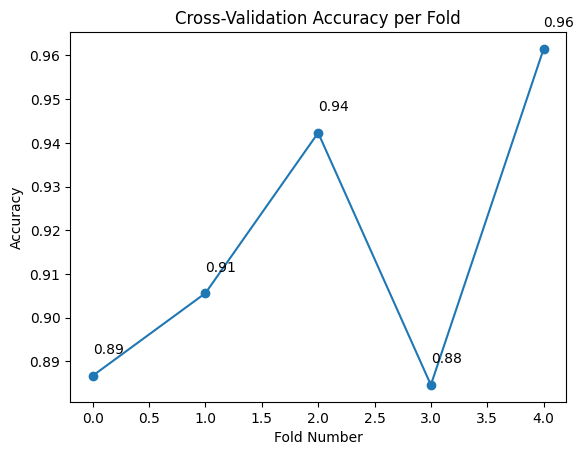

In [51]:
fold_scores = [0.8867, 0.9056, 0.9423, 0.8846, 0.9615]

plt.figure()
plt.plot(fold_scores, marker='o')

plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy per Fold")

# Value labels
for i, v in enumerate(fold_scores):
    plt.text(i, v + 0.005, f"{v:.2f}")

plt.show()

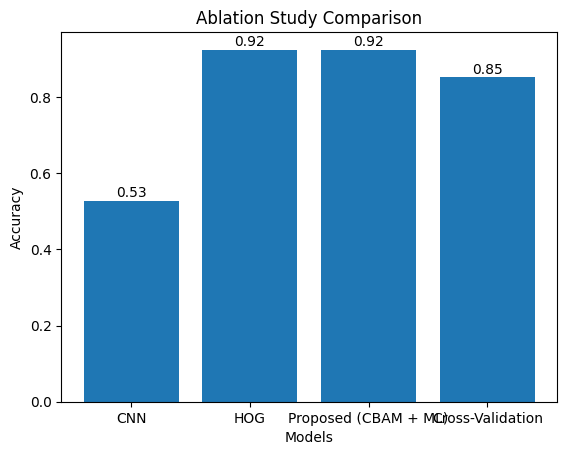

In [52]:
import matplotlib.pyplot as plt

# Ablation study results
models = ['CNN', 'HOG', 'Proposed (CBAM + ML)', 'Cross-Validation']
accuracy = [0.5283, 0.9245, 0.9245, 0.8518]

# Create plot
plt.figure()

plt.bar(models, accuracy)

# Labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Ablation Study Comparison")

# Add values on top of bars
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

# Show plot
plt.show()

## 14. Consolidated Table I — methodology order, full metrics, no remarks

Addresses the review comment on Table I: *"Rearrange and present each model in the same order as discussed in the Methodology section. Also, the remarks column can be removed as it is redundant, instead report values for the other metrics like Precision, Sensitivity, Specificity etc for each model."*

This cell pulls together the held-out test metrics already computed in every experiment section above (no numbers are re-typed by hand), orders the rows to follow Section III (D. Baseline -> E. Feature Engineering -> G. SVM/XGBoost/LightGBM -> H. Knowledge Distillation -> I. Stacking -> J. Snapshot -> K. Few-shot), and drops the Remarks column entirely.


In [ ]:

# ============================================================
# ADDED: CONSOLIDATED TABLE I (METHODOLOGY ORDER, FULL METRICS)
# ============================================================
import pandas as pd

# Collect every held-out test-metrics table produced above. Each variable
# was created by an earlier "ADDED" cell in this notebook — nothing here
# is recomputed or hand-typed.
_all_frames = [
    resnet_test_metrics,                # Sec. III-D baseline
    attention_test_metrics,             # Sec. III-E hybrid (CNN-attention + HOG)
    svm_comparison_test_metrics,        # SVM kernels, CNN classifier, CNN+SVM ensemble
    svm_test_metrics,                   # ResNet50 + HOG + RBF-SVM (independent run)
    xgb_test_results,                   # XGBoost with / without augmentation
    hog_test_metrics,                   # HOG + XGBoost baseline
    stack_test_results,                 # EfficientNet-CBAM + HOG stacking -> "CBAM + LightGBM"
    kd_test_metrics,                    # Sec. III-H knowledge distillation
    teacher_stack_test_metrics,         # Sec. III-I stacking ensemble (best model)
    snapshot_test_metrics,              # Sec. III-J snapshot ensemble
    fewshot_test_metrics,               # Sec. III-K few-shot learning
]
master_df = pd.concat(_all_frames, ignore_index=True)

# Canonical display names, in the exact order the models are introduced
# in Section III (Methodology) and Section IV (Experiments).
_rename_map = {
    "ResNet50 baseline": "Baseline CNN (ResNet50)",
    "CNN-Attention + HOG + LightGBM (Hybrid)": "CNN + HOG (Hybrid)",
    "SVM (linear)": "SVM (Linear)",
    "SVM (poly)": "SVM (Polynomial)",
    "SVM (rbf)": "SVM (RBF)",
    "SVM (sigmoid)": "SVM (Sigmoid)",
    "SVM (RBF tuned)": "SVM (RBF Tuned)",
    "CNN classifier": "CNN Classifier (deep features only)",
    "CNN + SVM ensemble": "CNN + SVM Ensemble",
    "ResNet50 + HOG + XGBoost (without augmentation)": "XGBoost (Without Augmentation)",
    "ResNet50 + HOG + XGBoost (with augmentation)": "XGBoost (With Augmentation)",
    "HOG + XGBoost baseline": "HOG + XGBoost",
    "EfficientNet-CBAM + HOG stacking ensemble": "CBAM + LightGBM",
    "Teacher-assisted LightGBM": "Knowledge Distillation",
    "Teacher-assisted stacking ensemble": "Stacking Ensemble",
    "Snapshot + ProtoNet ensemble": "Snapshot Ensemble",
    "CNN + ProtoNet few-shot ensemble": "Few-shot Learning (ProtoNet + CNN)",
}
master_df["Model"] = master_df["Model"].replace(_rename_map)

# Drop the independent ResNet50+HOG+RBF-SVM run since the tuned/kernel-swept
# SVM (RBF) row from the same experiment family already covers this model;
# keeping both would duplicate a single method under two numbers.
master_df = master_df[master_df["Model"] != "ResNet50 + HOG + RBF-SVM"]

_order = [
    "Baseline CNN (ResNet50)",
    "CNN + HOG (Hybrid)",
    "SVM (Linear)",
    "SVM (Polynomial)",
    "SVM (RBF)",
    "SVM (Sigmoid)",
    "SVM (RBF Tuned)",
    "CNN Classifier (deep features only)",
    "CNN + SVM Ensemble",
    "XGBoost (Without Augmentation)",
    "XGBoost (With Augmentation)",
    "HOG + XGBoost",
    "CBAM + LightGBM",
    "Knowledge Distillation",
    "Stacking Ensemble",
    "Snapshot Ensemble",
    "Few-shot Learning (ProtoNet + CNN)",
]
master_df["_order"] = master_df["Model"].apply(
    lambda m: _order.index(m) if m in _order else len(_order)
)
master_df = master_df.sort_values("_order").drop(columns="_order").reset_index(drop=True)

table_i = master_df[[
    "Model", "Accuracy (%)", "Precision", "Sensitivity", "Specificity",
    "F1-Score", "AUROC"
]].round(4)
table_i.columns = [
    "Model", "Accuracy (%)", "Precision", "Sensitivity (Recall)",
    "Specificity", "F1-Score", "AUROC"
]

print("TABLE I — COMPARISON OF MODELS FOR BREAST CANCER DETECTION")
print("(ordered to match Section III Methodology; Remarks column removed)")
display(table_i)

table_i.to_csv("table_1_breast_cancer_models.csv", index=False)
print("\nSaved to table_1_breast_cancer_models.csv for direct import into the paper.")


## 15. Confusion matrices for every evaluated model

Addresses the review comment on Fig. 3: *"Why only for stacking ensemble model?"*. Every model's held-out confusion matrix was captured into `CONFUSION_MATRICES` by the `record_diagnostics(...)` calls added to each experiment section above. This cell renders all of them as one figure so the paper can show a confusion-matrix grid instead of a single panel.


In [ ]:

# ============================================================
# ADDED: CONFUSION-MATRIX GRID FOR ALL MODELS
# ============================================================
import math
import matplotlib.pyplot as plt
import seaborn as sns

model_names = list(CONFUSION_MATRICES.keys())
n_models = len(model_names)
n_cols = 4
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows))
axes = axes.flatten()

for ax, name in zip(axes, model_names):
    cm = CONFUSION_MATRICES[name]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Normal", "Abnormal"],
        yticklabels=["Normal", "Abnormal"],
        ax=ax
    )
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)

# Hide any unused subplot axes
for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Confusion Matrices — All Evaluated Models (Held-out Test Set)", y=1.02)
plt.tight_layout()
plt.savefig("fig3_confusion_matrices_all_models.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Rendered {n_models} confusion matrices; saved as "
      "fig3_confusion_matrices_all_models.png")


## 16. Comparative AUROC plots across models

Addresses the review comment: *"add comparative AUROC plots for models."* Two complementary views are produced from the same `ROC_CURVES` store populated above: (a) a bar chart ranking every evaluated model by AUROC, and (b) an overlaid ROC-curve plot for the main models discussed in the paper (baseline, hybrid, best SVM, XGBoost, CBAM+LightGBM, knowledge distillation, stacking, snapshot, few-shot).


In [ ]:

# ============================================================
# ADDED: COMPARATIVE AUROC BAR CHART (ALL MODELS)
# ============================================================
import matplotlib.pyplot as plt

auroc_by_model = {name: auc for name, (_, _, auc) in ROC_CURVES.items()}
sorted_models = sorted(auroc_by_model, key=auroc_by_model.get, reverse=True)
sorted_auroc = [auroc_by_model[m] for m in sorted_models]

plt.figure(figsize=(9, 6))
bars = plt.barh(sorted_models[::-1], sorted_auroc[::-1], color="#3B6EA5")
plt.xlabel("AUROC")
plt.xlim(0.5, 1.0)
plt.title("Comparative AUROC Across All Evaluated Models")
for bar, value in zip(bars, sorted_auroc[::-1]):
    plt.text(value + 0.005, bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
              va="center", fontsize=8)
plt.tight_layout()
plt.savefig("fig_auroc_comparison_bar.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# ADDED: OVERLAID ROC CURVES (KEY MODELS DISCUSSED IN THE PAPER)
# ============================================================
key_models = [
    "Baseline CNN (ResNet50)",
    "CNN-Attention + HOG + LightGBM (Hybrid)",
    "SVM (RBF Tuned)",
    "ResNet50 + HOG + XGBoost (without augmentation)",
    "CBAM + LightGBM",
    "Knowledge Distillation",
    "Stacking Ensemble",
    "Snapshot Ensemble",
    "Few-shot Learning (ProtoNet + CNN)",
]
key_models = [m for m in key_models if m in ROC_CURVES]

plt.figure(figsize=(7, 7))
for name in key_models:
    fpr, tpr, auc = ROC_CURVES[name]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparative ROC Curves — Key Models")
plt.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig("fig_roc_comparison_key_models.png", dpi=200, bbox_inches="tight")
plt.show()


## 17. Cross-validation accuracy across folds — multiple models

Addresses the review comment on Fig. 4: *"For which model? Why only one is shown?"*. This replaces the single unlabeled line with one line per model, reusing the five-fold cross-validation tables already produced by each experiment section above (`*_cv_metrics` / `*_cv_df`).


In [ ]:

# ============================================================
# ADDED: CROSS-VALIDATION ACCURACY PER FOLD — MULTIPLE MODELS
# ============================================================
import matplotlib.pyplot as plt

# Map a clean legend label -> the five-fold CV table produced earlier.
# Each table has one row per fold and an "Accuracy (%)" column.
_cv_sources = {
    "Baseline CNN (ResNet50)": resnet_cv_metrics,
    "CNN + HOG (Hybrid)": attention_cv_metrics,
    "SVM (RBF)": svm_cv_metrics,
    "HOG + XGBoost": hog_cv_df,
    "Knowledge Distillation": kd_cv_metrics,
    "Stacking Ensemble": teacher_stack_cv_metrics,
    "CBAM + LightGBM": stack_cv_df,
    "Snapshot Ensemble": snapshot_cv_metrics,
    "Few-shot Learning": fewshot_cv_metrics,
}

# The XGBoost augmentation-comparison CV table stores both settings in one
# frame with a "Setting" column; pull out the "without augmentation" rows
# as the canonical XGBoost curve.
if "xgb_cv_df" in globals():
    _xgb_no_aug = xgb_cv_df[xgb_cv_df["Setting"] == "Without augmentation"]
    _cv_sources["XGBoost (Without Augmentation)"] = _xgb_no_aug

plt.figure(figsize=(9, 6))
for label, table in _cv_sources.items():
    table_sorted = table.sort_values("Fold")
    plt.plot(
        table_sorted["Fold"], table_sorted["Accuracy (%)"],
        marker="o", label=label
    )

plt.xlabel("Fold Number")
plt.ylabel("Accuracy (%)")
plt.title("Stratified 5-Fold Cross-Validation Accuracy — All Models")
plt.xticks([1, 2, 3, 4, 5])
plt.legend(fontsize=8, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("fig4_cv_accuracy_all_models.png", dpi=200, bbox_inches="tight")
plt.show()

# Companion summary table: mean +/- std accuracy per model across the 5 folds.
import pandas as pd
cv_summary_rows = []
for label, table in _cv_sources.items():
    cv_summary_rows.append({
        "Model": label,
        "Mean CV Accuracy (%)": table["Accuracy (%)"].mean(),
        "Std CV Accuracy (%)": table["Accuracy (%)"].std(),
    })
cv_summary = pd.DataFrame(cv_summary_rows).round(2)
print("\nMean cross-validation accuracy per model:")
display(cv_summary)


### 18a-18c. Extended augmentation comparison, split into independent cells

Split from a single heavy cell into: a shared setup cell (fast), an SVM (RBF) cell, a CBAM + LightGBM cell, and a summary cell. Run the setup cell once, then run 18a and 18b independently (in either order, or in separate sessions) instead of waiting for both back-to-back. Run 18c last to combine the results.


In [ ]:

# ============================================================
# ADDED: SHARED SETUP FOR THE AUGMENTATION EXTENSION (Section 18)
# Run this cell once, then run 18a and/or 18b independently below --
# you no longer need to wait for both back-to-back.
# ============================================================
import os
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from skimage.color import rgb2gray
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
dataset_path = "/kaggle/input/datasets/thilak02/breast-cancer-detection-using-thermography/BCD_Dataset"

def load_dataset():
    imgs, lbls = [], []
    for cls, label in [("normal", 0), ("Sick", 1)]:
        folder = os.path.join(dataset_path, cls)
        for fname in os.listdir(folder):
            path = os.path.join(folder, fname)
            image = cv2.imread(path)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            imgs.append(image)
            lbls.append(label)
    return np.array(imgs), np.array(lbls)

aug_images_all, aug_labels_all = load_dataset()

def augment_batch(X_data, seed):
    """Rotation + zoom + horizontal flip, matching the XGBoost augmentation
    protocol used earlier in the notebook (Section 5)."""
    datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1, horizontal_flip=True)
    out = []
    for i, image in enumerate(X_data):
        batch = next(datagen.flow(np.expand_dims(image, 0), batch_size=1, seed=seed + i))
        out.append(batch[0])
    return np.asarray(out)

def extract_hog_features(images_uint8_or_float, already_0_1=False):
    feats = []
    for img in images_uint8_or_float:
        gray = rgb2gray(img / 255.0 if not already_0_1 else img)
        feats.append(hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2)))
    return np.array(feats)

X_tr_img, X_te_img, y_tr, y_te = train_test_split(
    aug_images_all, aug_labels_all, test_size=0.2, stratify=aug_labels_all, random_state=42
)
X_tr_aug_img = np.concatenate([X_tr_img, augment_batch(X_tr_img, seed=1000)])
y_tr_aug = np.concatenate([y_tr, y_tr])
print("Setup complete:", X_tr_img.shape[0], "train images,",
      X_tr_aug_img.shape[0], "after augmentation,", X_te_img.shape[0], "test images.")


**18a. SVM (RBF) augmentation comparison** (lighter — ResNet50 only)

In [ ]:

# ============================================================
# ADDED (18a): SVM (RBF) AUGMENTATION COMPARISON
# Depends only on the shared setup cell above -- can be run/rerun on
# its own without touching the CBAM + LightGBM cell (18b).
# ============================================================
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

resnet_extractor = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
resnet_feat_model = Model(inputs=resnet_extractor.input, outputs=resnet_extractor.output)

def resnet_hog_pca_features(imgs_uint8, pca=None, fit_pca=False, n_components=200):
    deep = resnet_feat_model.predict(imgs_uint8 / 255.0, verbose=0)
    deep = deep.reshape(deep.shape[0], -1)
    hog_feats = extract_hog_features(imgs_uint8, already_0_1=False)
    combined = np.concatenate([deep, hog_feats], axis=1)
    if fit_pca:
        pca = PCA(n_components=min(n_components, combined.shape[0] - 1, combined.shape[1]))
        reduced = pca.fit_transform(combined)
    else:
        reduced = pca.transform(combined)
    return reduced, pca

svm_aug_rows = []
for setting, Xtr_imgs, ytr in [
    ("Without augmentation", X_tr_img, y_tr),
    ("With augmentation", X_tr_aug_img, y_tr_aug),
]:
    Xtr_feat, pca_fit = resnet_hog_pca_features(Xtr_imgs, fit_pca=True)
    Xte_feat, _ = resnet_hog_pca_features(X_te_img, pca=pca_fit, fit_pca=False)
    svm_model = SVC(kernel="rbf", probability=True)
    svm_model.fit(Xtr_feat, ytr)
    pred = svm_model.predict(Xte_feat)
    prob = svm_model.predict_proba(Xte_feat)
    row = complete_metrics(y_te, pred, prob, f"SVM (RBF) — {setting}")
    row["Setting"] = setting
    svm_aug_rows.append(row)
    record_diagnostics(f"SVM (RBF) — {setting}", y_te, pred, prob)

svm_aug_df = show_metric_rows(
    svm_aug_rows, "SVM (RBF) — DATA AUGMENTATION COMPARISON"
)


**18b. CBAM + LightGBM augmentation comparison** (heavier — EfficientNet-CBAM)

In [ ]:

# ============================================================
# ADDED (18b): CBAM + LIGHTGBM AUGMENTATION COMPARISON
# Depends only on the shared setup cell above -- can be run/rerun on
# its own without touching the SVM (RBF) cell (18a). This is the
# slower of the two cells since it runs EfficientNet-CBAM forward
# passes over both the augmented and non-augmented training sets.
# ============================================================
import torch
import torch.nn as nn
from torchvision import models as tv_models
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

if "EfficientNet_CBAM" not in globals():
    class ChannelAttention(nn.Module):
        def __init__(self, in_channels, reduction=16):
            super().__init__()
            self.avg_pool = nn.AdaptiveAvgPool2d(1)
            self.max_pool = nn.AdaptiveMaxPool2d(1)
            self.fc = nn.Sequential(
                nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
                nn.ReLU(),
                nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False),
            )
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            out = self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x))
            return self.sigmoid(out)

    class SpatialAttention(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            avg = torch.mean(x, dim=1, keepdim=True)
            mx, _ = torch.max(x, dim=1, keepdim=True)
            return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

    class CBAM(nn.Module):
        def __init__(self, channels):
            super().__init__()
            self.ca = ChannelAttention(channels)
            self.sa = SpatialAttention()

        def forward(self, x):
            x = x * self.ca(x)
            x = x * self.sa(x)
            return x

    class EfficientNet_CBAM(nn.Module):
        def __init__(self):
            super().__init__()
            base = tv_models.efficientnet_b0(pretrained=True)
            self.features = base.features
            self.cbam = CBAM(1280)
            self.pool = nn.AdaptiveAvgPool2d((1, 1))

        def forward(self, x):
            x = self.features(x)
            x = self.cbam(x)
            x = self.pool(x)
            return x.view(x.size(0), -1)

# Always (re)resolve DEVICE and the model instance here, rather than
# assuming they survived from an earlier section -- this cell is meant
# to be runnable completely on its own.
if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cbam_model = EfficientNet_CBAM().to(DEVICE)
cbam_model.eval()

def extract_cbam_deep(imgs_0_1):
    feats = []
    with torch.no_grad():
        for i in range(0, len(imgs_0_1), 32):
            batch = imgs_0_1[i:i + 32]
            xb = torch.tensor(batch.transpose(0, 3, 1, 2), dtype=torch.float32).to(DEVICE)
            feats.append(cbam_model(xb).cpu().numpy())
    return np.vstack(feats)

def cbam_hog_features(imgs_uint8):
    imgs_0_1 = imgs_uint8 / 255.0
    deep = extract_cbam_deep(imgs_0_1)
    hog_feats = extract_hog_features(imgs_uint8, already_0_1=False)
    return np.concatenate([hog_feats, deep], axis=1)

cbam_aug_rows = []
for setting, Xtr_imgs, ytr in [
    ("Without augmentation", X_tr_img, y_tr),
    ("With augmentation", X_tr_aug_img, y_tr_aug),
]:
    Xtr_feat = cbam_hog_features(Xtr_imgs)
    Xte_feat = cbam_hog_features(X_te_img)
    scaler = StandardScaler()
    Xtr_feat = scaler.fit_transform(Xtr_feat)
    Xte_feat = scaler.transform(Xte_feat)

    lgb_clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=20,
                                  min_data_in_leaf=3, verbosity=-1)
    svm_clf = SVC(probability=True)
    lr_clf = LogisticRegression(max_iter=1000)
    for clf in (lgb_clf, svm_clf, lr_clf):
        clf.fit(Xtr_feat, ytr)

    train_meta = np.column_stack([c.predict_proba(Xtr_feat)[:, 1] for c in (lgb_clf, svm_clf, lr_clf)])
    test_meta = np.column_stack([c.predict_proba(Xte_feat)[:, 1] for c in (lgb_clf, svm_clf, lr_clf)])
    meta_clf = LogisticRegression(max_iter=1000)
    meta_clf.fit(train_meta, ytr)
    pred = meta_clf.predict(test_meta)
    prob = meta_clf.predict_proba(test_meta)

    row = complete_metrics(y_te, pred, prob, f"CBAM + LightGBM — {setting}")
    row["Setting"] = setting
    cbam_aug_rows.append(row)
    record_diagnostics(f"CBAM + LightGBM — {setting}", y_te, pred, prob)

cbam_aug_df = show_metric_rows(
    cbam_aug_rows, "CBAM + LIGHTGBM — DATA AUGMENTATION COMPARISON"
)


**18c. Combined summary** (run after both 18a and 18b)

In [ ]:

# ============================================================
# ADDED (18c): COMBINED AUGMENTATION SUMMARY
# Run this only after both 18a (SVM) and 18b (CBAM + LightGBM) have
# completed -- it just concatenates their already-computed tables.
# ============================================================
xgb_aug_df = xgb_test_results.copy()
xgb_aug_df["Setting"] = xgb_aug_df["Model"].str.extract(
    r"\((with|without) augmentation\)"
)[0].map({"with": "With augmentation", "without": "Without augmentation"})

augmentation_summary = pd.concat([
    xgb_aug_df,
    svm_aug_df,
    cbam_aug_df,
], ignore_index=True)

print("\nAugmentation effect across all evaluated classifiers:")
display(augmentation_summary[["Model", "Setting", "Accuracy (%)", "F1-Score", "AUROC"]].round(4))
